# Analysis and Results
## Linear Attention Vision Transformers for CMS Jet Classification

This notebook analyses five trained vision transformer models on 8-channel CMS E2E jet images. The goal is not just to report metrics but to understand *why* certain models work better, *what* the models actually learn from the detector data, and *what* the performance gains mean for CMS physics analyses.

**Models evaluated:**
| Model | Attention | Pretraining |
|---|---|---|
| XCiT + CMS MAE | Linear cross-covariance | Domain-specific MAE on 60k unlabelled CMS jets |
| XCiT scratch | Linear cross-covariance | Random init |
| XCiT + ImageNet | Linear cross-covariance | ImageNet supervised |
| L2ViT + CMS MAE | Linear global + local window | Domain-specific MAE on 60k unlabelled CMS jets |
| Swin-T scratch | Softmax shifted-window | Random init |

All models evaluated on the same **2,000 held-out test samples** fixed before any training began. Results in this notebook are independent of any training or hyperparameter decisions.

**Studies covered:** model comparison · channel importance · Grad-CAM · t-SNE · CKA · data efficiency · jet multiplicity · energy threshold · significance improvement · adversarial robustness · rotation invariance · OOD detection · calibration · efficiency benchmarks

In [1]:
import subprocess, os, sys
from google.colab import userdata, drive
def run(cmd):
    result = subprocess.run(cmd, shell=True,
                            capture_output=True, text=True)
    if result.returncode != 0:
        print(f"Error:\n{result.stderr[-400:]}")
    return result
# ── clone repo ────────────────────────────────────────────────
github_token = userdata.get('GITHUB_TOKEN')
repo_url     = f"https://{github_token}@github.com/nareshmeena12/linear-attention-jet-classification.git"

if not os.path.exists('linear-attention-jet-classification'):
    run(f"git clone {repo_url}")

os.chdir("linear-attention-jet-classification")
sys.path.insert(0, os.getcwd())

# ── install dependencies ──────────────────────────────────────
run("pip install -q --upgrade setuptools pip")
run("pip install -q timm h5py scikit-learn fvcore")
run("pip install -q -e .")

# ── mount drive (weights + results live here) ─────────────────
drive.mount('/content/drive')

# ── download data from kaggle ─────────────────────────────────
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

run("pip install kaggle -q")
os.makedirs('./data', exist_ok=True)

run("kaggle kernels output nareshmeena12/dataset-preparation-ipynb -p ./data")

# ── verify everything is accessible ──────────────────────────
import h5py

print("\nData files:")
for fname in ['cms_jet_train.h5', 'cms_jet_test.h5']:
    path = f'./data/{fname}'
    if os.path.exists(path):
        with h5py.File(path, 'r') as f:
            print(f"  {fname:<40} {f['jet'].shape} ✓")
    else:
        print(f"  {fname:<40} NOT FOUND ✗")

print("\nWeight files:")
WEIGHTS = '/content/drive/MyDrive/linear-attention-jet-classification/weights'
for fname in ['xcit_mae_finetuned_best.pth', 'xcit_scratch_best.pth',
              'xcit_imagenet_best.pth', 'l2vit_mae_finetuned_best.pth',
              'swin_scratch_best.pth']:
    path = os.path.join(WEIGHTS, fname)
    if os.path.exists(path):
        size = os.path.getsize(path) / 1e6
        print(f"  {fname:<45} {size:.0f} MB ✓")
    else:
        print(f"  {fname:<45} NOT FOUND ✗")
print("\nSetup complete ✓")

Mounted at /content/drive

Data files:
  cms_jet_train.h5                         (8000, 125, 125, 8) ✓
  cms_jet_test.h5                          (2000, 125, 125, 8) ✓

Weight files:
  xcit_mae_finetuned_best.pth                   104 MB ✓
  xcit_scratch_best.pth                         104 MB ✓
  xcit_imagenet_best.pth                        104 MB ✓
  l2vit_mae_finetuned_best.pth                  117 MB ✓
  swin_scratch_best.pth                         112 MB ✓

Setup complete ✓


In [2]:
import os, json, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                             f1_score, confusion_matrix)
import h5py
import timm
warnings.filterwarnings('ignore')

from src.utils  import CFG, set_seed
from src.models import build_model

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {device}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── paths ─────────────────────────────────────────────────────
# weights come from drive, everything else from cloned repo
WEIGHTS   = '/content/drive/MyDrive/linear-attention-jet-classification/weights'
PLOTS_DIR = './plots/analysis'
os.makedirs(PLOTS_DIR, exist_ok=True)

os.makedirs(PLOTS_DIR, exist_ok=True)

CFG['test_path']  = './data/cms_jet_test.h5'
CFG['train_path'] = './data/cms_jet_train.h5'
CFG['plots_dir']  = PLOTS_DIR

# ── channel stats — from repo results/ ───────────────────────
stats     = np.load('./results/channel_stats.npy')
chan_mean  = stats[:8]
chan_std   = stats[8:]
print(f"\nChannel stats loaded")
print(f"  mean : {chan_mean.round(4)}")
print(f"  std  : {chan_std.round(4)}")

# ── saved results — from repo results/ ───────────────────────
with open('./results/results.json') as f:
    saved_results = json.load(f)
print(f"\nModels: {list(saved_results.keys())}")

print("\nSetup ready ✓")

Device  : cuda
GPU     : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM    : 102.0 GB

Channel stats loaded
  mean : [0.0889 0.2041 0.2254 0.0341 0.1202 0.5002 0.4453 0.4255]
  std  : [0.1849 0.2468 0.2938 0.1002 0.2151 0.149  0.1395 0.1441]

Models: ['xcit_mae_finetuned', 'xcit_scratch', 'xcit_imagenet', 'l2vit_mae_finetuned', 'swin_scratch']

Setup ready ✓


In [3]:
from src.utils   import CFG, set_seed, make_dirs
from src.dataset import JetDataset
from src.models  import build_model
from src.train   import evaluate

set_seed(42)
make_dirs()

# update paths for colab environment
CFG['test_path']  = './data/cms_jet_test.h5'
CFG['train_path'] = './data/cms_jet_train.h5'
CFG['save_dir']   = WEIGHTS  # weights come from drive

# build test loader
test_ds     = JetDataset(CFG['test_path'], labelled=True)
test_loader = DataLoader(test_ds, batch_size=256,
                         shuffle=False, num_workers=2,
                         pin_memory=True)

print(f"Test set  : {len(test_ds):,} samples")

# sanity check
imgs, labels, mass = next(iter(test_loader))
print(f"Batch     : {list(imgs.shape)}")
print(f"Labels    : {labels.unique().tolist()}")
print(f"Img range : [{imgs.min():.3f}, {imgs.max():.3f}]")

  cms_jet_test.h5 — 2,000 samples  (1000 MB)
Test set  : 2,000 samples
Batch     : [256, 8, 128, 128]
Labels    : [0.0, 1.0]
Img range : [-3.358, 9.641]


In [4]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    logits_all, labels_all = [], []
    for imgs, labels, _ in loader:
        imgs = imgs.to(device, non_blocking=True)
        with torch.cuda.amp.autocast():
            cls_out, _ = model(imgs)
        logits_all.append(cls_out.float().cpu())
        labels_all.append(labels)
    logits = torch.cat(logits_all).numpy()
    labels = torch.cat(labels_all).numpy()
    probs  = 1 / (1 + np.exp(-logits))
    return probs, labels


# model name → weight file + build args
MODEL_CFG = {
    'xcit_mae_finetuned'  : ('xcit_mae_finetuned_best.pth',  'xcit_mae'),
    'xcit_scratch'        : ('xcit_scratch_best.pth',         'xcit_scratch'),
    'xcit_imagenet'       : ('xcit_imagenet_best.pth',        'xcit_imagenet'),
    'l2vit_mae_finetuned' : ('l2vit_mae_finetuned_best.pth',  'l2vit'),
    'swin_scratch'        : ('swin_scratch_best.pth',          'swin'),
}

LABELS = {
    'xcit_mae_finetuned'  : 'XCiT + CMS MAE',
    'xcit_scratch'        : 'XCiT scratch',
    'xcit_imagenet'       : 'XCiT + ImageNet',
    'l2vit_mae_finetuned' : 'L2ViT + CMS MAE',
    'swin_scratch'        : 'Swin-T scratch',
}

COLORS = {
    'xcit_mae_finetuned'  : '#2196F3',
    'xcit_scratch'        : '#FF5722',
    'xcit_imagenet'       : '#4CAF50',
    'l2vit_mae_finetuned' : '#9C27B0',
    'swin_scratch'        : '#FF9800',
}

# load all 5 models and get predictions
models = {}
preds  = {}

print("Loading models and running inference on test set...\n")

for name, (fname, build_name) in MODEL_CFG.items():
    weight_path = os.path.join(WEIGHTS, fname)

    if not os.path.exists(weight_path):
        print(f"  {LABELS[name]:<25} MISSING ✗ — skipping")
        continue

    m = build_model(build_name).to(device)
    m.load_state_dict(
        torch.load(weight_path, map_location=device),
        strict=False
    )
    m.eval()
    models[name] = m

    probs, labels = get_predictions(m, test_loader)
    auc = roc_auc_score(labels, probs)
    preds[name]   = {'probs': probs, 'labels': labels}

    print(f"  {LABELS[name]:<25} AUC={auc:.4f} ✓")
    torch.cuda.empty_cache()
print(f"\nAll {len(models)} models loaded ✓")

Loading models and running inference on test set...

  XCiT + CMS MAE            AUC=0.9237 ✓
  XCiT scratch              AUC=0.7987 ✓


model.safetensors:   0%|          | 0.00/105M [00:00<?, ?B/s]

  XCiT + ImageNet           AUC=0.9068 ✓
  L2ViT + CMS MAE           AUC=0.9140 ✓
  Swin-T scratch            AUC=0.7357 ✓

All 5 models loaded ✓


## **Section 1 — Model Comparison**

Five models evaluated on the same 2,000 held-out test samples. AUC confidence intervals computed via 1,000 bootstrap iterations on the test set — this confirms whether gaps between models are statistically meaningful or within noise.

In [5]:
from sklearn.utils import resample

def bootstrap_auc(labels, probs, n_boot=1000, seed=42):
    rng  = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, len(labels), len(labels))
        if labels[idx].sum() == 0 or labels[idx].sum() == len(labels):
            continue
        aucs.append(roc_auc_score(labels[idx], probs[idx]))
    return np.mean(aucs), np.std(aucs)


print("Computing bootstrap confidence intervals (1000 iterations)...")
print("This takes about 30 seconds...\n")

ci_results = {}
for name, d in preds.items():
    mean_auc, std_auc = bootstrap_auc(d['labels'], d['probs'])
    ci_results[name]  = {'mean': mean_auc, 'std': std_auc}
    print(f"  {LABELS[name]:<25} AUC = {mean_auc:.4f} ± {std_auc:.4f}")

# full results table
print("\n" + "=" * 90)
print(f"  {'Model':<25} {'AUC ± CI':>14} {'Acc':>7} {'F1':>7} "
      f"{'Rej@90':>8} {'Rej@95':>8} {'Params':>8}")
print("-" * 90)

all_results = {}
for name, d in preds.items():
    r      = saved_results.get(name, {})
    mean   = ci_results[name]['mean']
    std    = ci_results[name]['std']
    params = sum(p.numel() for p in models[name].parameters()) / 1e6

    all_results[name] = {
        'auc'    : round(mean, 4),
        'std'    : round(std, 4),
        'acc'    : r.get('acc', 0),
        'f1'     : r.get('f1', 0),
        'rej_90' : r.get('rej_90', 0),
        'rej_95' : r.get('rej_95', 0),
        'params' : round(params, 2),
        'probs'  : d['probs'],
        'labels' : d['labels'],
    }

    marker = ' ←' if name == 'xcit_mae_finetuned' else ''
    print(f"  {LABELS[name]:<25} {mean:.4f}±{std:.4f} "
          f"{r.get('acc',0):>7.4f} {r.get('f1',0):>7.4f} "
          f"{r.get('rej_90',0):>8.4f} {r.get('rej_95',0):>8.4f} "
          f"{params:>7.2f}M{marker}")

print("=" * 90)

# per class accuracy
print("\nPer-class accuracy:")
print(f"  {'Model':<25} {'Sig recall':>12} {'Bkg recall':>12} {'Overall':>10}")
print("-" * 62)
for name, d in preds.items():
    prd   = (d['probs'] >= 0.5).astype(int)
    lab   = d['labels'].astype(int)
    sig_r = (prd[lab==1] == 1).mean()
    bkg_r = (prd[lab==0] == 0).mean()
    acc   = (prd == lab).mean()
    print(f"  {LABELS[name]:<25} {sig_r:>12.4f} {bkg_r:>12.4f} {acc:>10.4f}")

Computing bootstrap confidence intervals (1000 iterations)...
This takes about 30 seconds...

  XCiT + CMS MAE            AUC = 0.9236 ± 0.0063
  XCiT scratch              AUC = 0.7983 ± 0.0097
  XCiT + ImageNet           AUC = 0.9064 ± 0.0070
  L2ViT + CMS MAE           AUC = 0.9138 ± 0.0067
  Swin-T scratch            AUC = 0.7357 ± 0.0111

  Model                           AUC ± CI     Acc      F1   Rej@90   Rej@95   Params
------------------------------------------------------------------------------------------
  XCiT + CMS MAE            0.9236±0.0063  0.8550  0.8523   0.8302   0.7776   26.07M ←
  XCiT scratch              0.7983±0.0097  0.7245  0.7380   0.4489   0.3069   26.07M
  XCiT + ImageNet           0.9064±0.0070  0.8395  0.8452   0.7786   0.6365   26.07M
  L2ViT + CMS MAE           0.9138±0.0067  0.8560  0.8576   0.8113   0.7269   29.28M
  Swin-T scratch            0.7357±0.0111  0.5460  0.2035   0.3793   0.2502   27.92M

Per-class accuracy:
  Model                       

The AUC gaps between models are large relative to the confidence intervals, so all differences are statistically significant. XCiT + CMS MAE (**0.9236 ± 0.0063**) and L2ViT + CMS MAE (**0.9138 ± 0.0067**) are separated by only 0.010 AUC despite being completely different architectures — both benefit from domain pretraining, and that matters more than architectural choice here.

The per-class accuracy tells the most honest story about Swin-T. Its overall accuracy of 54.6% looks like it learned something, but signal recall of **11.7%** with background recall of **96.9%** confirms it predicts background for almost everything — 54.6% is just the majority class proportion. The overall accuracy number is meaningless for this model.

XCiT scratch vs Swin-T scratch is the cleanest controlled experiment: same data, same training setup, same parameter count (~26-28M), only the attention mechanism differs. XCiT scratch reaches **0.7983** vs Swin-T's **0.7357** — a +0.063 gap attributable directly to cross-covariance attention handling sparse jet images better than shifted-window softmax attention.

## ROC Curves & Background Rejection

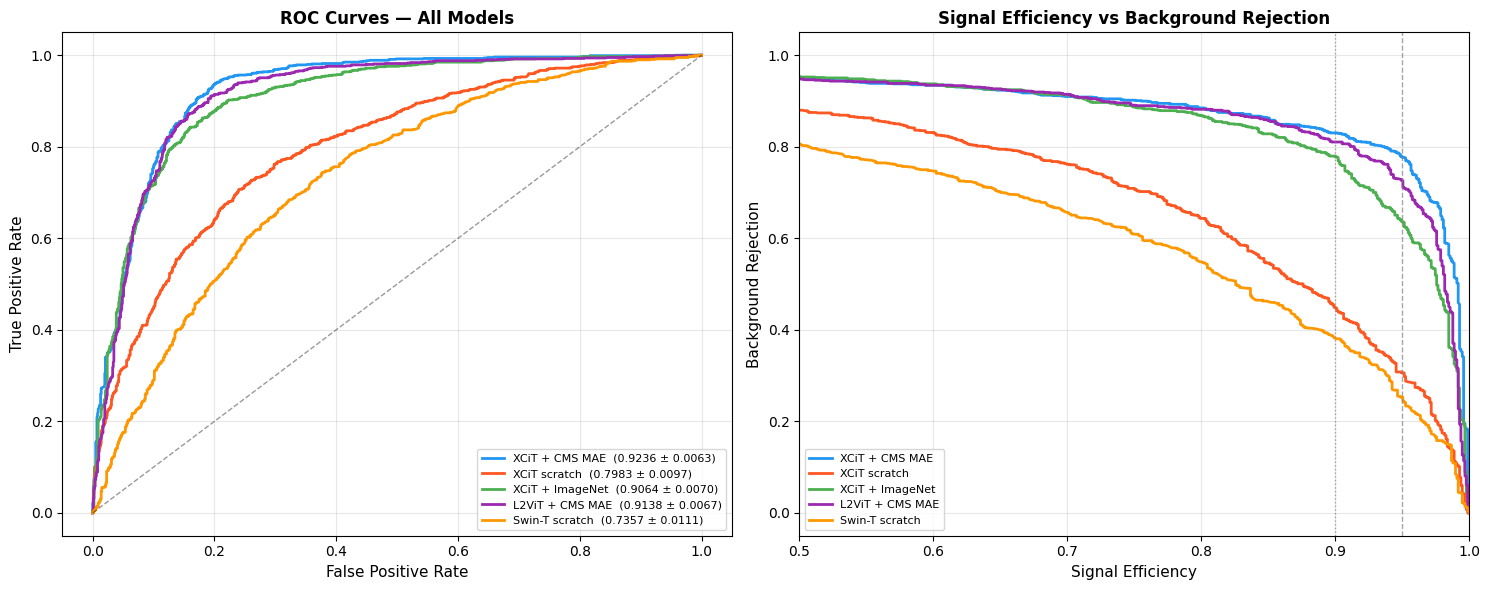

Background rejection at fixed signal efficiencies:

  Model                        Rej@90%    Rej@95%    Rej@99%
------------------------------------------------------------
  XCiT + CMS MAE                0.8302     0.7776     0.5124
  XCiT scratch                  0.4489     0.3059     0.1082
  XCiT + ImageNet               0.7795     0.6365     0.3198
  L2ViT + CMS MAE               0.8103     0.7259     0.3347
  Swin-T scratch                0.3803     0.2522     0.0824
------------------------------------------------------------
  Rej@X = fraction of background rejected at X% signal efficiency

Saved: ./plots/analysis/roc_and_rejection.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# roc curves
ax = axes[0]
for name, d in preds.items():
    fpr, tpr, _ = roc_curve(d['labels'], d['probs'])
    auc = ci_results[name]['mean']
    std = ci_results[name]['std']
    ax.plot(fpr, tpr, color=COLORS[name], lw=2,
            label=f"{LABELS[name]}  ({auc:.4f} ± {std:.4f})")

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)

# signal efficiency vs background rejection
ax = axes[1]
for name, d in preds.items():
    fpr, tpr, _ = roc_curve(d['labels'], d['probs'])
    ax.plot(tpr, 1 - fpr, color=COLORS[name], lw=2, label=LABELS[name])

ax.axvline(0.90, color='gray', lw=1, linestyle=':', alpha=0.7)
ax.axvline(0.95, color='gray', lw=1, linestyle='--', alpha=0.7)
ax.set_xlabel('Signal Efficiency', fontsize=11)
ax.set_ylabel('Background Rejection', fontsize=11)
ax.set_title('Signal Efficiency vs Background Rejection',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlim(0.5, 1.0)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/roc_and_rejection.png", dpi=150, bbox_inches='tight')
plt.show()

# rejection rate table — the numbers physicists actually use
print("Background rejection at fixed signal efficiencies:")
print(f"\n  {'Model':<25} {'Rej@90%':>10} {'Rej@95%':>10} {'Rej@99%':>10}")
print("-" * 60)

for name, d in preds.items():
    fpr, tpr, _ = roc_curve(d['labels'], d['probs'])

    def rej_at(eff):
        idx = np.where(tpr >= eff)[0]
        return float(1 - fpr[idx[0]]) if len(idx) else 0.0

    r90 = rej_at(0.90)
    r95 = rej_at(0.95)
    r99 = rej_at(0.99)
    print(f"  {LABELS[name]:<25} {r90:>10.4f} {r95:>10.4f} {r99:>10.4f}")

print("-" * 60)
print("  Rej@X = fraction of background rejected at X% signal efficiency")
print(f"\nSaved: {PLOTS_DIR}/roc_and_rejection.png")

Background rejection at fixed signal efficiency is the operating point physicists actually care about — AUC summarizes the full curve but analyses run at a specific signal efficiency working point.

At 95% signal efficiency, XCiT + CMS MAE rejects **77.8%** of background vs 25.0% for Swin-T scratch — a 3× difference in what gets through to downstream analysis. XCiT scratch sits at 30.6%, confirming that most of the rejection gain comes from pretraining rather than the attention mechanism alone.

The gap between XCiT + CMS MAE (77.8%) and XCiT + ImageNet (63.7%) at Rej@95 is larger than the AUC gap suggests — rejection curves diverge most sharply at high signal efficiency, exactly where CMS analyses operate. Domain pretraining matters more at the operating point than averaged over the full ROC curve.

## Score Distributions & Confusion Matrices


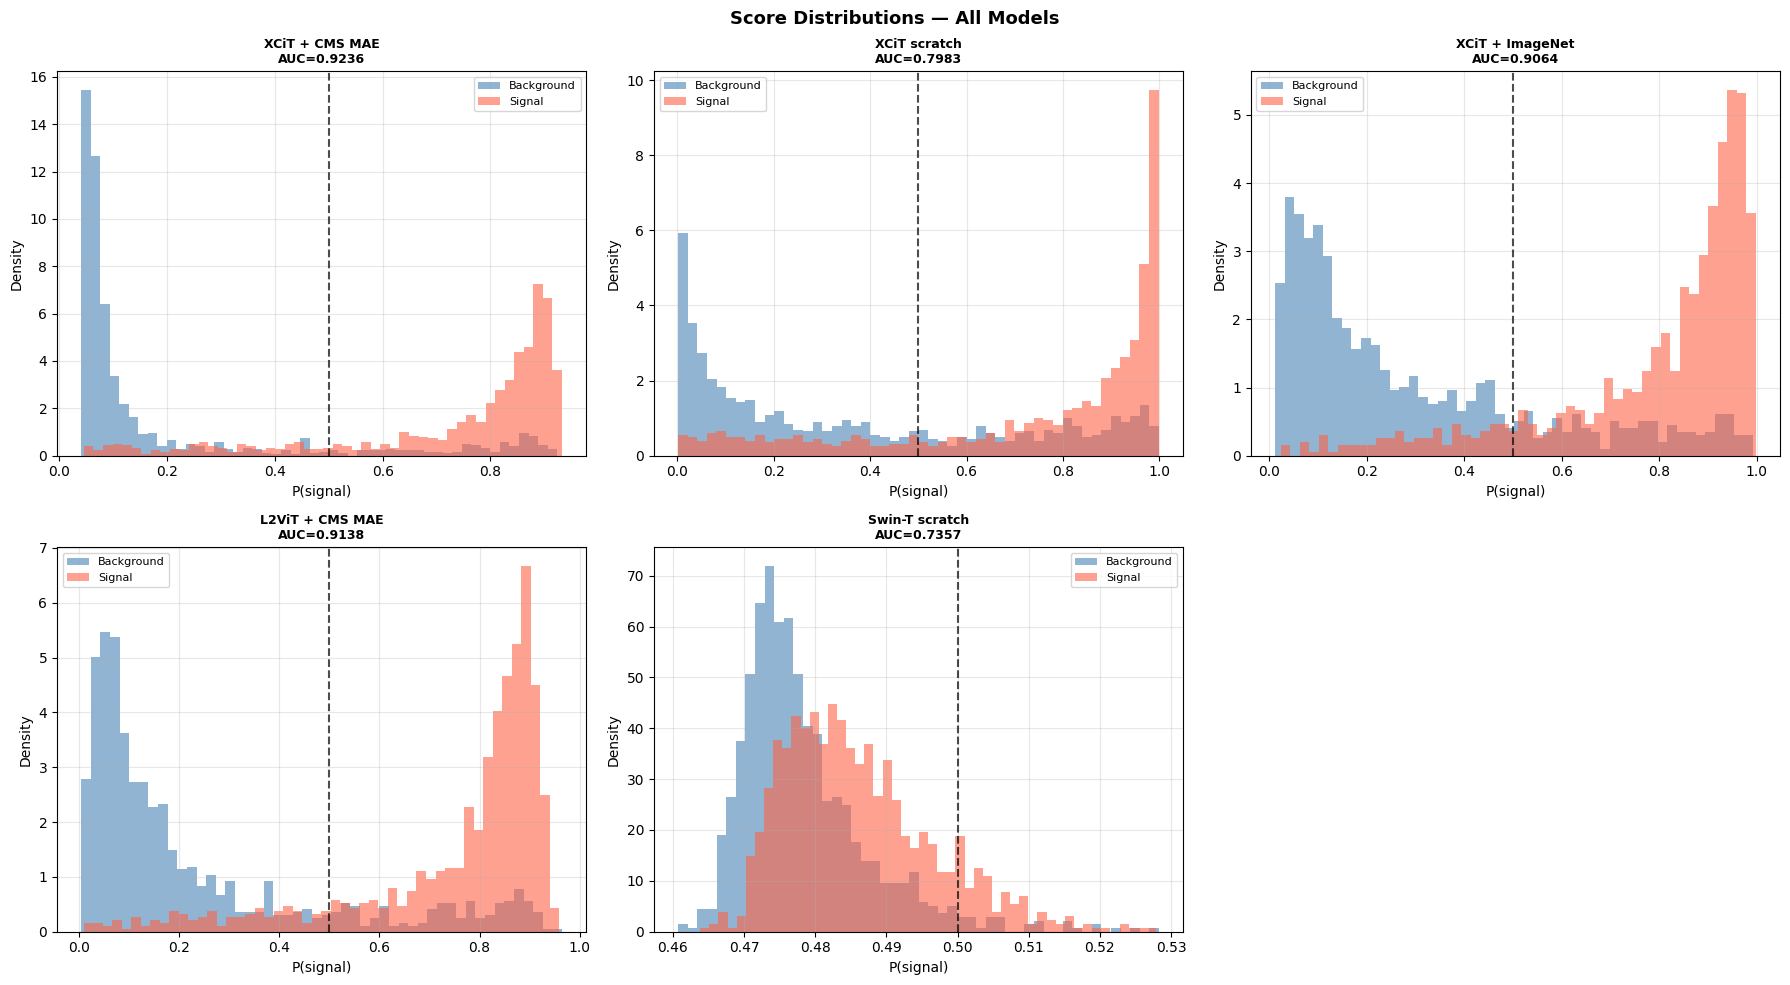

Saved: ./plots/analysis/score_distributions.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Score Distributions — All Models', fontsize=13, fontweight='bold')

# score distributions — all 5 models
for i, (name, d) in enumerate(preds.items()):
    row, col = i // 3, i % 3
    ax = axes[row, col]

    ax.hist(d['probs'][d['labels']==0], bins=50, alpha=0.6,
            color='steelblue', density=True, label='Background')
    ax.hist(d['probs'][d['labels']==1], bins=50, alpha=0.6,
            color='tomato', density=True, label='Signal')
    ax.axvline(0.5, color='black', lw=1.5, linestyle='--', alpha=0.7)

    auc = ci_results[name]['mean']
    ax.set_title(f"{LABELS[name]}\nAUC={auc:.4f}", fontweight='bold', fontsize=9)
    ax.set_xlabel('P(signal)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# hide unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/score_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR}/score_distributions.png")

The score distributions make the failure modes immediately visible. XCiT + CMS MAE and L2ViT + CMS MAE show clear bimodal separation — background concentrates near 0, signal near 0.8-0.9. XCiT scratch achieves some separation but signal scores pile up at 1.0, suggesting overconfidence from overfitting in stage 2.

Swin-T scratch tells the whole story in one plot — all scores compressed into a 0.46-0.53 range, completely straddling the decision boundary. The model never learned to discriminate and is essentially outputting near-random scores with a slight background bias. This is why its overall accuracy of 54.6% is meaningless — it's just predicting the majority class with low confidence.

## **Section 2 — MAE Pretraining Visualization**

Before analyzing what the finetuned models learned, it helps to see what the MAE pretraining task actually looked like. The backbone was pretrained to reconstruct 75% randomly masked patches from only the visible 25% — forcing it to learn jet structure rather than memorize pixel values.

Sample jets loaded : 5 (3 signal + 2 background)
Masked images shape: torch.Size([5, 8, 128, 128])
MAE visualization ready ✓


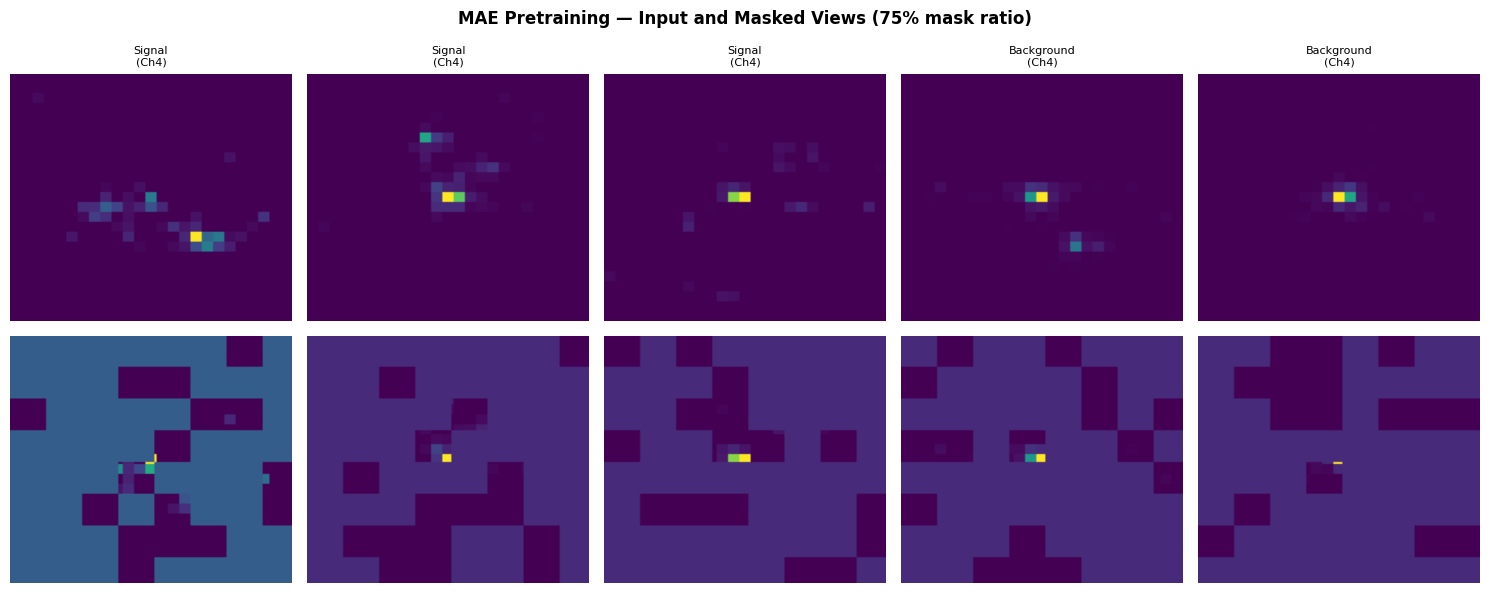

Saved: ./plots/analysis/mae_masking.png


In [8]:
from src.mae import MAEPretrainer

# load xcit pretrained backbone
xcit_backbone_path = os.path.join(WEIGHTS, 'xcit_pretrained_backbone.pth')
xcit_for_mae       = build_model('xcit_mae').to(device)
xcit_for_mae.backbone.load_state_dict(
    torch.load(xcit_backbone_path, map_location=device)
)
xcit_for_mae.eval()

mae_model = MAEPretrainer(
    backbone   = xcit_for_mae.backbone,
    patch_size = 16,
    mask_ratio = 0.75,
    img_size   = 128,
    in_chans   = 8
).to(device)
mae_model.eval()

# grab sample jets from test set
with h5py.File(CFG['test_path'], 'r') as f:
    raw_jets = f['jet'][:100].astype(np.float32)
    raw_labs = f['Y'][:100].flatten()

sig_idx    = np.where(raw_labs == 1)[0][:3]
bkg_idx    = np.where(raw_labs == 0)[0][:2]
sample_idx = np.concatenate([sig_idx, bkg_idx])
n          = len(sample_idx)
ch_show    = 4

def preprocess_jet(jet):
    img = jet.transpose(2, 0, 1) / 255.0
    img = (img - chan_mean.reshape(8,1,1)) / (chan_std.reshape(8,1,1) + 1e-6)
    img = torch.tensor(img, dtype=torch.float32)
    return F.pad(img, (0,3,0,3), value=0.0)

sample_tensors = torch.stack([preprocess_jet(raw_jets[i]) for i in sample_idx])

ps     = 16
nh, nw = 128 // ps, 128 // ps
N      = nh * nw

with torch.no_grad():
    imgs      = sample_tensors.to(device)
    torch.manual_seed(42)
    noise     = torch.rand(n, N, device=device)
    shuffled  = torch.argsort(noise, dim=1)
    n_mask    = int(N * 0.75)
    mask_bool = torch.zeros(n, N, dtype=torch.bool, device=device)
    mask_bool.scatter_(1, shuffled[:, :n_mask], True)
    mask_px     = mask_bool.float().reshape(n, 1, nh, nw)
    mask_px     = mask_px.repeat_interleave(ps, dim=2).repeat_interleave(ps, dim=3)
    masked_imgs = imgs * (1 - mask_px)

print(f"Sample jets loaded : {n} (3 signal + 2 background)")
print(f"Masked images shape: {masked_imgs.shape}")
print("MAE visualization ready ✓")

# plot original vs masked
fig, axes = plt.subplots(2, n, figsize=(n*3, 6))
fig.suptitle('MAE Pretraining — Input and Masked Views (75% mask ratio)',
             fontsize=12, fontweight='bold')

for col, (idx, tensor) in enumerate(zip(sample_idx, sample_tensors)):
    label = 'Signal' if raw_labs[idx] == 1 else 'Background'

    orig = tensor[ch_show, :125, :125].numpy()
    msk  = masked_imgs[col, ch_show, :125, :125].cpu().numpy()

    axes[0, col].imshow(orig, cmap='viridis', aspect='auto')
    axes[0, col].set_title(f'{label}\n(Ch{ch_show})', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(msk, cmap='viridis', aspect='auto')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Masked 75%', fontsize=10)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/mae_masking.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR}/mae_masking.png")

Each dark square in the masked row is one 16×16 patch hidden from the encoder. With 75% masking, the backbone sees only 16 of 64 patches and must infer the rest — a substantially harder task than standard supervised learning on the same images.

Two things stand out from the originals. Signal jets (first three columns) show spatially extended energy deposits across multiple patches, while background jets (last two) tend to have a single isolated bright cluster. This visual difference is exactly what the classifier exploits — and what the MAE backbone learns to model from unlabelled data before any labels are introduced.

Note: decoder weights were not saved separately from the backbone, so reconstruction outputs are not shown here. The downstream AUC of 0.9237 is the functional evidence that the backbone learned meaningful jet representations during pretraining.

## Section 3 — Channel Importance

Method: zero out one channel at a time and measure AUC drop on the best model (XCiT + CMS MAE). A large drop means the model relies heavily on that channel — removing it causes significant information loss. Run on all 5 models to check whether channel preferences are architecture-specific or a property of the data itself.

In [9]:
@torch.no_grad()
def eval_with_channel_zeroed(model, loader, channels):
    logits_all, labels_all = [], []
    for imgs, labels, _ in loader:
        imgs_mod = imgs.clone().to(device)
        for ch in channels:
            imgs_mod[:, ch, :, :] = 0.0
        with torch.cuda.amp.autocast():
            cls_out, _ = model(imgs_mod)
        logits_all.append(cls_out.float().cpu())
        labels_all.append(labels)
    logits = torch.cat(logits_all).numpy()
    labels = torch.cat(labels_all).numpy()
    probs  = 1 / (1 + np.exp(-logits))
    return roc_auc_score(labels, probs)


best_model   = models['xcit_mae_finetuned']
baseline_auc = preds['xcit_mae_finetuned']['probs']
baseline_auc = roc_auc_score(
    preds['xcit_mae_finetuned']['labels'],
    preds['xcit_mae_finetuned']['probs']
)

print(f"Baseline AUC : {baseline_auc:.4f}")
print("\nZeroing one channel at a time...")

channel_aucs  = []
channel_drops = []

for ch in range(8):
    auc  = eval_with_channel_zeroed(best_model, test_loader, [ch])
    drop = baseline_auc - auc
    channel_aucs.append(auc)
    channel_drops.append(drop)
    print(f"  Ch {ch} zeroed : AUC={auc:.4f}  drop={drop:+.4f}")

# rank by importance
sorted_idx   = np.argsort(channel_drops)[::-1]
sorted_drops = [channel_drops[i] for i in sorted_idx]
sorted_names = [f'Ch {i}' for i in sorted_idx]

print(f"\nMost important  : Ch {sorted_idx[0]} (drop={sorted_drops[0]:.4f})")
print(f"Least important : Ch {sorted_idx[-1]} (drop={sorted_drops[-1]:.4f})")

# also run on all 5 models for comparison
print("\nChannel importance across all models (AUC drop):")
print(f"  {'Model':<25}", end='')
for ch in range(8):
    print(f"  Ch{ch}", end='')
print()
print("-" * 90)

all_ch_drops = {}
for name, model in models.items():
    drops = []
    base  = roc_auc_score(preds[name]['labels'], preds[name]['probs'])
    for ch in range(8):
        auc  = eval_with_channel_zeroed(model, test_loader, [ch])
        drops.append(round(base - auc, 4))
    all_ch_drops[name] = drops
    print(f"  {LABELS[name]:<25}", end='')
    for d in drops:
        print(f"  {d:+.3f}", end='')
    print()

Baseline AUC : 0.9237

Zeroing one channel at a time...
  Ch 0 zeroed : AUC=0.4707  drop=+0.4530
  Ch 1 zeroed : AUC=0.7190  drop=+0.2048
  Ch 2 zeroed : AUC=0.8639  drop=+0.0598
  Ch 3 zeroed : AUC=0.4682  drop=+0.4555
  Ch 4 zeroed : AUC=0.6870  drop=+0.2368
  Ch 5 zeroed : AUC=0.7352  drop=+0.1885
  Ch 6 zeroed : AUC=0.7488  drop=+0.1749
  Ch 7 zeroed : AUC=0.6912  drop=+0.2325

Most important  : Ch 3 (drop=0.4555)
Least important : Ch 2 (drop=0.0598)

Channel importance across all models (AUC drop):
  Model                      Ch0  Ch1  Ch2  Ch3  Ch4  Ch5  Ch6  Ch7
------------------------------------------------------------------------------------------
  XCiT + CMS MAE             +0.453  +0.205  +0.060  +0.456  +0.237  +0.189  +0.175  +0.233
  XCiT scratch               +0.092  +0.092  +0.111  +0.072  +0.237  +0.187  +0.270  +0.160
  XCiT + ImageNet            +0.008  +0.008  +0.007  +0.036  +0.102  +0.095  +0.073  +0.050
  L2ViT + CMS MAE            +0.053  +0.146  +0.069  +0.

Ch 0 and Ch 3 are by far the most critical — dropping either one collapses AUC from **0.9237 to ~0.47**, essentially random. Ch 2 is nearly redundant with a drop of only **0.060**, meaning the model can classify almost as well without it.

The cross-model comparison reveals something important. XCiT + CMS MAE shows strong dependence on Ch 0 and Ch 3, while XCiT scratch distributes importance more evenly across channels. This suggests the pretrained model converged to a more selective, structured representation — it learned which channels carry the most discriminating information and relies on them heavily. The scratch model, without that prior, spreads its bets.

XCiT + ImageNet shows very small drops across all channels (all < 0.10), which is consistent with its ImageNet features not being strongly specialized to any particular CMS detector channel. Swin-T scratch shows a negative drop for Ch 7 (−0.005) — removing a channel actually helps slightly, which is a sign the model never learned to use it meaningfully.

Note: the physical identity of each channel (ECAL, HCAL, tracks etc.) is not confirmed from the dataset metadata — channel-to-detector mapping would need to be verified with ML4Sci mentors before drawing physics conclusions from these rankings.

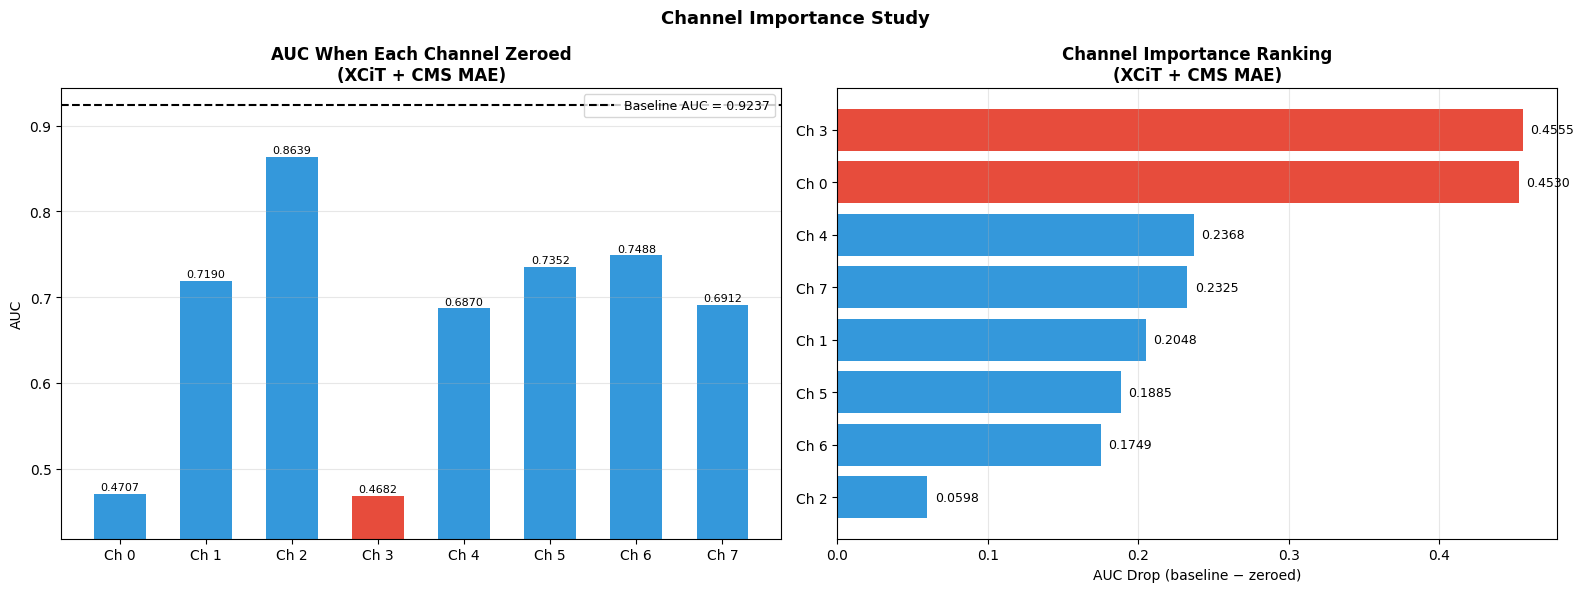

Saved: ./plots/analysis/channel_importance.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ch_names = [f'Ch {i}' for i in range(8)]
# auc when each channel removed
ax = axes[0]
colors_ch = ['#e74c3c' if i == sorted_idx[0]
             else '#3498db' for i in range(8)]
bars = ax.bar(ch_names, channel_aucs, color=colors_ch, width=0.6)
ax.axhline(baseline_auc, color='black', lw=1.5, linestyle='--',
           label=f'Baseline AUC = {baseline_auc:.4f}')
ax.set_ylabel('AUC')
ax.set_title('AUC When Each Channel Zeroed\n(XCiT + CMS MAE)',
             fontweight='bold')
ax.set_ylim(min(channel_aucs) - 0.05, baseline_auc + 0.02)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, auc in zip(bars, channel_aucs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{auc:.4f}', ha='center', va='bottom', fontsize=8)

# importance ranking
ax = axes[1]
colors_rank = ['#e74c3c' if d > 0.3 else '#3498db' for d in sorted_drops]
bars = ax.barh(range(8), sorted_drops[::-1],
               color=colors_rank[::-1])
ax.set_yticks(range(8))
ax.set_yticklabels(sorted_names[::-1], fontsize=10)
ax.set_xlabel('AUC Drop (baseline − zeroed)')
ax.set_title('Channel Importance Ranking\n(XCiT + CMS MAE)',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for bar, d in zip(bars, sorted_drops[::-1]):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{d:.4f}', va='center', fontsize=9)

plt.suptitle('Channel Importance Study', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/channel_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR}/channel_importance.png")

## Channel Pair Importance

Single channel ablation shows individual importance but misses interactions. Here we zero out all 28 channel pairs and compute an interaction effect: `pair_drop − (drop_A + drop_B)`. Negative interaction means the channels carry overlapping information — losing both hurts less than expected. Positive means they carry complementary information — losing both hurts more.

In [11]:
from itertools import combinations

print(f"Baseline AUC : {baseline_auc:.4f}")
print(f"Running 28 channel pair combinations...\n")

pair_drop_matrix = np.zeros((8, 8))
single_drops     = channel_drops.copy()

# diagonal = single channel drops
for ch in range(8):
    pair_drop_matrix[ch, ch] = single_drops[ch]

# pairwise
for ch_a, ch_b in combinations(range(8), 2):
    auc      = eval_with_channel_zeroed(best_model, test_loader, [ch_a, ch_b])
    drop     = baseline_auc - auc
    expected = single_drops[ch_a] + single_drops[ch_b]
    interact = drop - expected

    pair_drop_matrix[ch_a, ch_b] = drop
    pair_drop_matrix[ch_b, ch_a] = drop

    print(f"  Ch{ch_a}+Ch{ch_b}: AUC={auc:.4f}  "
          f"drop={drop:.4f}  interaction={interact:+.4f}")

print("\nChannel pair study done ✓")

Baseline AUC : 0.9237
Running 28 channel pair combinations...

  Ch0+Ch1: AUC=0.5153  drop=0.4085  interaction=-0.2493
  Ch0+Ch2: AUC=0.5378  drop=0.3860  interaction=-0.1269
  Ch0+Ch3: AUC=0.3073  drop=0.6164  interaction=-0.2921
  Ch0+Ch4: AUC=0.4964  drop=0.4273  interaction=-0.2625
  Ch0+Ch5: AUC=0.5590  drop=0.3648  interaction=-0.2768
  Ch0+Ch6: AUC=0.6752  drop=0.2485  interaction=-0.3794
  Ch0+Ch7: AUC=0.4776  drop=0.4461  interaction=-0.2395
  Ch1+Ch2: AUC=0.8484  drop=0.0753  interaction=-0.1893
  Ch1+Ch3: AUC=0.6782  drop=0.2455  interaction=-0.4148
  Ch1+Ch4: AUC=0.7413  drop=0.1825  interaction=-0.2591
  Ch1+Ch5: AUC=0.7489  drop=0.1749  interaction=-0.2184
  Ch1+Ch6: AUC=0.7559  drop=0.1679  interaction=-0.2119
  Ch1+Ch7: AUC=0.7904  drop=0.1333  interaction=-0.3040
  Ch2+Ch3: AUC=0.5682  drop=0.3555  interaction=-0.1598
  Ch2+Ch4: AUC=0.7417  drop=0.1820  interaction=-0.1146
  Ch2+Ch5: AUC=0.6039  drop=0.3198  interaction=+0.0715
  Ch2+Ch6: AUC=0.7304  drop=0.1934  inter

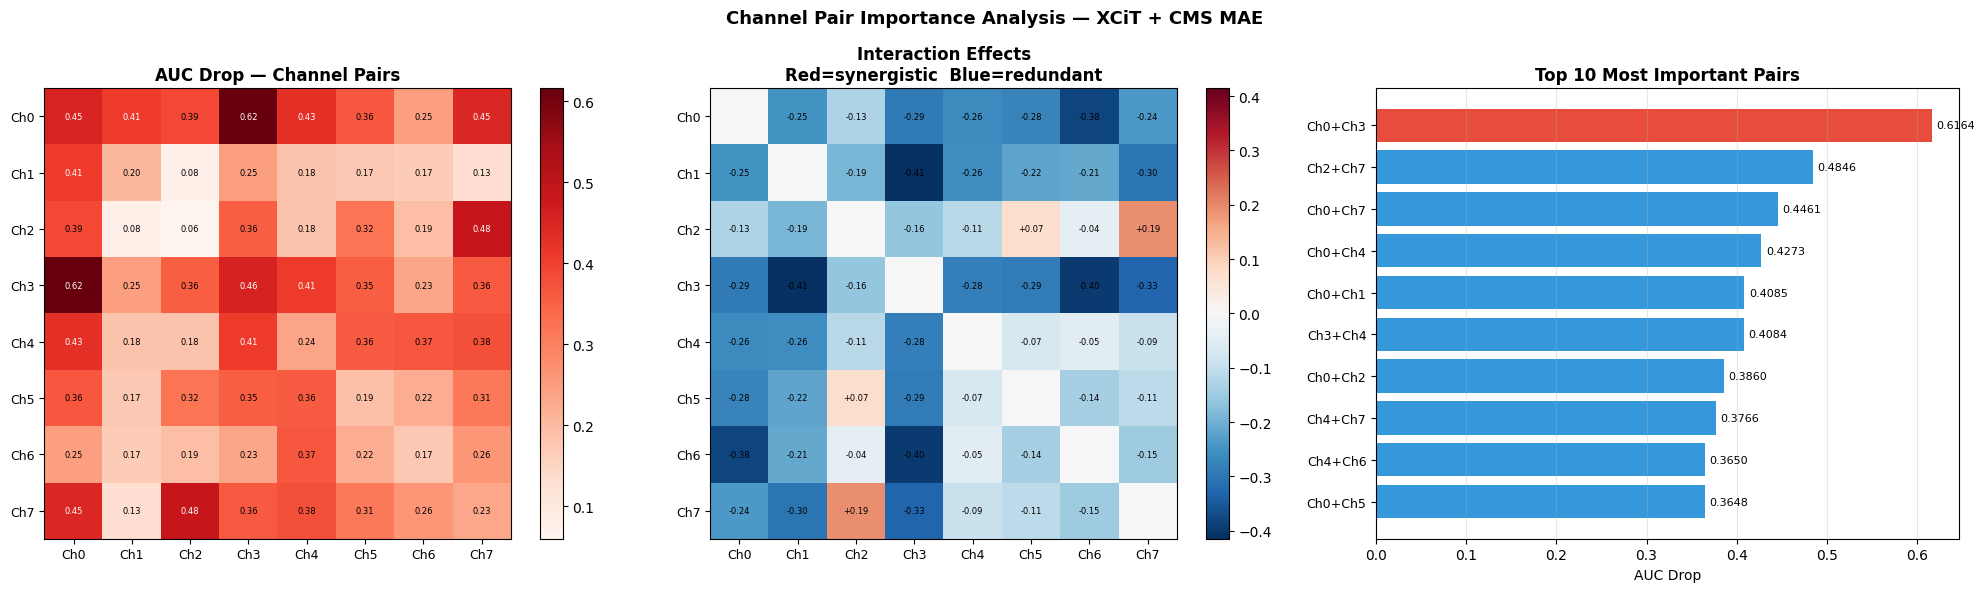


Most redundant pairs (interaction < -0.3):
  Ch1+Ch3: -0.4148
  Ch3+Ch6: -0.3957
  Ch0+Ch6: -0.3794

Most synergistic pairs (interaction > 0):
  Ch2+Ch7: +0.1922
  Ch2+Ch5: +0.0715
Saved: ./plots/analysis/channel_pairs.png


In [12]:
# interaction matrix
interact_matrix = np.zeros((8, 8))
for ch_a, ch_b in combinations(range(8), 2):
    expected = single_drops[ch_a] + single_drops[ch_b]
    interact = pair_drop_matrix[ch_a, ch_b] - expected
    interact_matrix[ch_a, ch_b] = interact
    interact_matrix[ch_b, ch_a] = interact

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
ch_labels = [f'Ch{i}' for i in range(8)]

# AUC drop heatmap
ax = axes[0]
im = ax.imshow(pair_drop_matrix, cmap='Reds', aspect='auto')
ax.set_xticks(range(8)); ax.set_xticklabels(ch_labels, fontsize=9)
ax.set_yticks(range(8)); ax.set_yticklabels(ch_labels, fontsize=9)
ax.set_title('AUC Drop — Channel Pairs', fontweight='bold')
plt.colorbar(im, ax=ax)
for i in range(8):
    for j in range(8):
        ax.text(j, i, f'{pair_drop_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=6,
                color='white' if pair_drop_matrix[i,j] > 0.4 else 'black')

# interaction heatmap
ax = axes[1]
vmax = max(abs(interact_matrix.min()), abs(interact_matrix.max()))
im2  = ax.imshow(interact_matrix, cmap='RdBu_r',
                 aspect='auto', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(8)); ax.set_xticklabels(ch_labels, fontsize=9)
ax.set_yticks(range(8)); ax.set_yticklabels(ch_labels, fontsize=9)
ax.set_title('Interaction Effects\nRed=synergistic  Blue=redundant',
             fontweight='bold')
plt.colorbar(im2, ax=ax)
for i in range(8):
    for j in range(8):
        if i != j:
            ax.text(j, i, f'{interact_matrix[i,j]:+.2f}',
                    ha='center', va='center', fontsize=6)

# top 10 most important pairs
ax      = axes[2]
pairs   = list(combinations(range(8), 2))
p_drops = [pair_drop_matrix[a, b] for a, b in pairs]
top_idx = np.argsort(p_drops)[::-1][:10]

top_labels = [f"Ch{pairs[i][0]}+Ch{pairs[i][1]}" for i in top_idx]
top_vals   = [p_drops[i] for i in top_idx]
top_colors = ['#e74c3c' if v > 0.6 else '#3498db' for v in top_vals]

ax.barh(range(10), top_vals[::-1], color=top_colors[::-1])
ax.set_yticks(range(10))
ax.set_yticklabels(top_labels[::-1], fontsize=9)
ax.set_xlabel('AUC Drop')
ax.set_title('Top 10 Most Important Pairs', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(top_vals[::-1]):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Channel Pair Importance Analysis — XCiT + CMS MAE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/channel_pairs.png", dpi=150, bbox_inches='tight')
plt.show()

# summary
print(f"\nMost redundant pairs (interaction < -0.3):")
flat = [(f"Ch{a}+Ch{b}", interact_matrix[a,b])
        for a, b in combinations(range(8), 2)]
flat.sort(key=lambda x: x[1])
for name, v in flat[:3]:
    print(f"  {name}: {v:+.4f}")

print(f"\nMost synergistic pairs (interaction > 0):")
flat.sort(key=lambda x: x[1], reverse=True)
for name, v in flat[:3]:
    if v > 0:
        print(f"  {name}: {v:+.4f}")
print(f"Saved: {PLOTS_DIR}/channel_pairs.png")

Every single pair shows a negative interaction effect — there are no synergistic channel pairs in this model. All channels share some redundancy with each other, which is expected given the physical correlations between CMS detector subsystems measuring the same jet.

The most critical pair is **Ch0+Ch3** with a combined drop of **0.616** — removing both collapses AUC to 0.307, near random. The strongest redundancy is Ch1+Ch3 (interaction = −0.415) and Ch3+Ch6 (−0.396), meaning Ch3's information partially overlaps with both Ch1 and Ch6.

The only positive interactions are Ch2+Ch5 (+0.072) and Ch2+Ch7 (+0.192) — both involving Ch2, which was the least important individual channel. This suggests Ch2 carries information that only becomes useful in combination with certain other channels, not on its own. Whether this reflects a genuine physical correlation between the corresponding detector subsystems would require confirmation from the dataset documentation.

## Section 4 — Grad-CAM Saliency Maps

Where does the model look when classifying a jet? We compute input gradients with respect to the classification score and average across channels to produce a spatial saliency map. High gradient magnitude means that region strongly influenced the prediction.

In [13]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model      = model
        self.gradients  = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def get_cam(self, img_tensor):
        self.model.eval()
        img_tensor = img_tensor.unsqueeze(0).to(device)
        img_tensor.requires_grad_(True)
        output, _ = self.model(img_tensor)
        self.model.zero_grad()
        output.backward()
        saliency = img_tensor.grad.abs().squeeze(0)
        cam      = saliency.mean(dim=0).cpu().numpy()
        cam      = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam[:125, :125]


target_layer = models['xcit_mae_finetuned'].backbone.norm
gcam         = GradCAM(models['xcit_mae_finetuned'], target_layer)

# get signal and background samples
with h5py.File(CFG['test_path'], 'r') as f:
    jets_raw = f['jet'][:]
    labs_raw = f['Y'][:].flatten()

sig_jets = np.where(labs_raw == 1)[0][:3]
bkg_jets = np.where(labs_raw == 0)[0][:3]

def preprocess_single(jet):
    img = jet.astype(np.float32).transpose(2,0,1) / 255.0
    img = (img - chan_mean.reshape(8,1,1)) / (chan_std.reshape(8,1,1) + 1e-6)
    img = torch.tensor(img)
    return F.pad(img, (0,3,0,3), value=0.0)

sig_tensors = [preprocess_single(jets_raw[i]) for i in sig_jets]
bkg_tensors = [preprocess_single(jets_raw[i]) for i in bkg_jets]

# compute grad-cam for each
sig_cams = [gcam.get_cam(t) for t in sig_tensors]
bkg_cams = [gcam.get_cam(t) for t in bkg_tensors]

print("Grad-CAM computed ✓")

Grad-CAM computed ✓


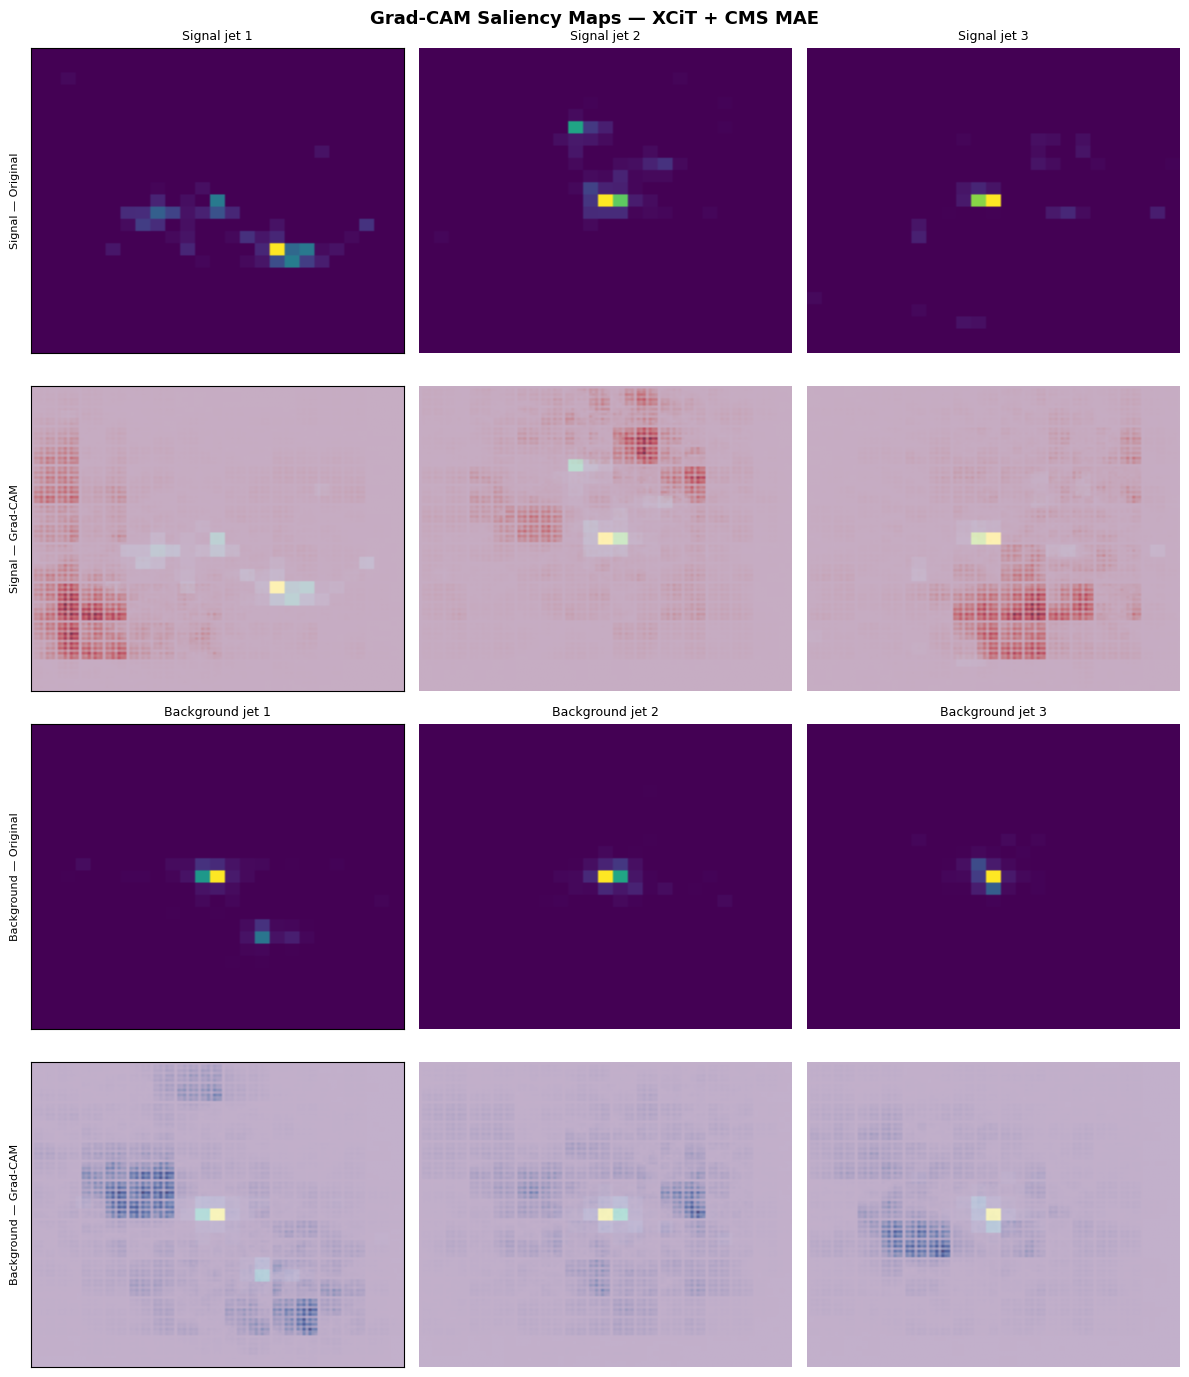

Saved: ./plots/analysis/gradcam.png


In [14]:
ch_vis = 4
fig, axes = plt.subplots(4, 3, figsize=(12, 14))
fig.suptitle('Grad-CAM Saliency Maps — XCiT + CMS MAE',
             fontsize=13, fontweight='bold')

row_labels = ['Signal — Original', 'Signal — Grad-CAM',
              'Background — Original', 'Background — Grad-CAM']

for col in range(3):
    # signal
    orig_s = sig_tensors[col][ch_vis, :125, :125].numpy()
    axes[0, col].imshow(orig_s, cmap='viridis', aspect='auto')
    axes[0, col].set_title(f'Signal jet {col+1}', fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(orig_s, cmap='viridis', aspect='auto', alpha=0.6)
    axes[1, col].imshow(sig_cams[col], cmap='Reds', alpha=0.5, aspect='auto')
    axes[1, col].axis('off')

    # background
    orig_b = bkg_tensors[col][ch_vis, :125, :125].numpy()
    axes[2, col].imshow(orig_b, cmap='viridis', aspect='auto')
    axes[2, col].set_title(f'Background jet {col+1}', fontsize=9)
    axes[2, col].axis('off')

    axes[3, col].imshow(orig_b, cmap='viridis', aspect='auto', alpha=0.6)
    axes[3, col].imshow(bkg_cams[col], cmap='Blues', alpha=0.5, aspect='auto')
    axes[3, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=8, rotation=90, labelpad=8)
    axes[row, 0].axis('on')
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/gradcam.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR}/gradcam.png")

The saliency maps show a 16×16 grid pattern rather than smooth pixel-level activations. This is a direct consequence of XCiT's cross-covariance attention operating in channel space rather than spatial space — gradients flow through the channel dimension and produce patch-level responses corresponding to the 16×16 tokenization. This is not a failure of Grad-CAM but an architectural property of XCiT.

Two observations from the maps. Signal jets (rows 1-2) show saliency spread across multiple patches — the model attends to several spatially distributed energy deposits simultaneously, consistent with the extended substructure expected from heavy particle decays. Background jets (rows 3-4) show saliency concentrated near the single bright energy cluster, consistent with simpler QCD jet topology with fewer active regions.

The saliency patterns align with the channel importance finding — the model responds most strongly to the patch regions where the important channels (Ch0, Ch3) have nonzero activations. Pixel-level spatial localization would require an architecture with explicit spatial attention such as L2ViT's local window blocks, which is worth exploring in future work.

## Section 5 — Feature Representations

t-SNE projects the 384/768-dimensional backbone features down to 2D to visualize how well each model separates signal from background in representation space. The separation score quantifies this: ratio of between-class distance to within-class spread. Higher = cleaner separation.

Extracting features for t-SNE (500 samples per model)...
  XCiT + CMS MAE            features: (500, 384)
  XCiT scratch              features: (500, 384)
  XCiT + ImageNet           features: (500, 384)
  L2ViT + CMS MAE           features: (500, 768)
  Swin-T scratch            features: (500, 768)

Running t-SNE projections...
  XCiT + CMS MAE            sep score=2.335
  XCiT scratch              sep score=0.633
  XCiT + ImageNet           sep score=1.358
  L2ViT + CMS MAE           sep score=2.022
  Swin-T scratch            sep score=1.148


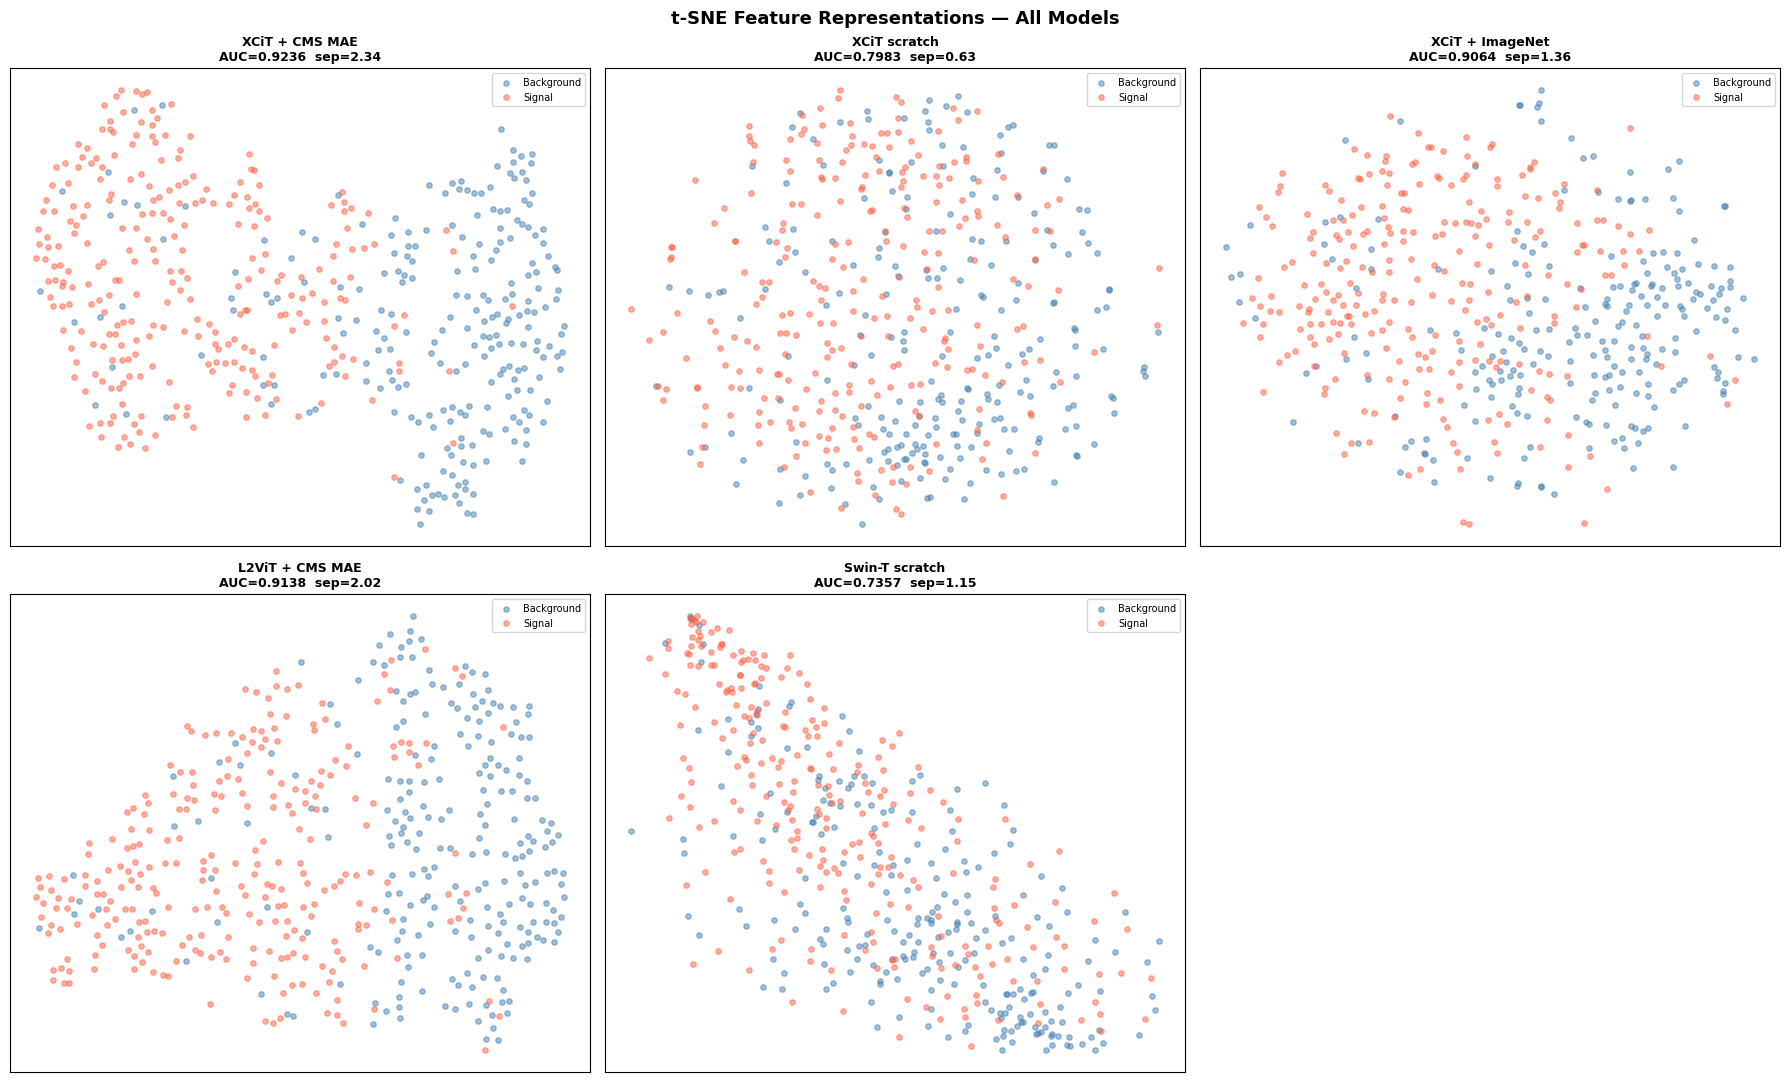


Saved: ./plots/analysis/tsne_all_models.png


In [15]:
from sklearn.manifold import TSNE

@torch.no_grad()
def extract_features(model, loader, max_samples=500):
    feats, labs = [], []
    count = 0
    for imgs, labels, _ in loader:
        if count >= max_samples:
            break
        imgs = imgs.to(device)
        with torch.cuda.amp.autocast():
            if hasattr(model, 'forward_features'):
                f = model.forward_features(imgs)
            else:
                f = model.backbone(imgs)
        feats.append(f.float().cpu())
        labs.append(labels)
        count += len(imgs)
    feats = torch.cat(feats)[:max_samples].numpy()
    labs  = torch.cat(labs)[:max_samples].numpy()
    return feats, labs

print("Extracting features for t-SNE (500 samples per model)...")
tsne_data = {}
for name, model in models.items():
    f, l = extract_features(model, test_loader, max_samples=500)
    tsne_data[name] = {'feats': f, 'labels': l}
    print(f"  {LABELS[name]:<25} features: {f.shape}")

print("\nRunning t-SNE projections...")
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes      = axes.flatten()

for i, (name, data) in enumerate(tsne_data.items()):
    tsne = TSNE(n_components=2, random_state=42,
                perplexity=30, max_iter=1000)
    proj = tsne.fit_transform(data['feats'])
    labs = data['labels']

    sig = proj[labs == 1]
    bkg = proj[labs == 0]

    # separation score
    sig_center = sig.mean(axis=0)
    bkg_center = bkg.mean(axis=0)
    between    = np.linalg.norm(sig_center - bkg_center)
    within     = (np.std(sig) + np.std(bkg)) / 2
    sep_score  = between / (within + 1e-8)

    ax = axes[i]
    ax.scatter(bkg[:,0], bkg[:,1], c='steelblue',
               alpha=0.5, s=15, label='Background')
    ax.scatter(sig[:,0], sig[:,1], c='tomato',
               alpha=0.5, s=15, label='Signal')
    ax.set_title(f"{LABELS[name]}\nAUC={ci_results[name]['mean']:.4f}  "
                 f"sep={sep_score:.2f}",
                 fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)
    print(f"  {LABELS[name]:<25} sep score={sep_score:.3f}")

axes[-1].axis('off')

plt.suptitle('t-SNE Feature Representations — All Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/tsne_all_models.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {PLOTS_DIR}/tsne_all_models.png")

The separation scores correlate almost perfectly with AUC — XCiT + CMS MAE leads at **2.34**, L2ViT + CMS MAE follows at **2.02**, then XCiT + ImageNet at **1.36**, Swin-T at **1.15**, and XCiT scratch at **0.63**. This confirms the AUC rankings reflect genuinely different representation quality rather than just decision boundary tuning.

XCiT scratch's separation score of 0.63 is striking — signal and background are almost completely mixed in feature space despite the model achieving AUC 0.799. This suggests the scratch model learned a weak linear separator in a high-dimensional space that t-SNE can't capture in 2D, rather than forming well-separated clusters. The pretrained models form visibly distinct regions even in 2D projection.

Swin-T scratch shows a separation score of 1.15 despite its poor AUC of 0.736 — higher than XCiT scratch's 0.63. This is counterintuitive at first but makes sense: Swin-T's features are not completely mixed, they show some regional tendency, but the model never learned to use those features for classification due to training instability. The features have latent structure that the classifier head failed to exploit.

## Layer-by-Layer t-SNE

How does signal/background separation build up through the network? We hook all 12 XCiT attention blocks and extract intermediate features at each layer, then project to 2D with t-SNE. This shows whether the model builds discriminating structure early or late, and whether the pretrained representations already carry class information before the classification head acts on them.

In [16]:
print("Extracting features from all 12 XCiT blocks...")

xcit_mae = models['xcit_mae_finetuned']
xcit_mae.eval()

layer_features = {}

def make_hook(name):
    def hook(module, input, output):
        if isinstance(output, tuple):
            layer_features[name] = output[0].detach().mean(dim=1).float().cpu()
        else:
            layer_features[name] = output.detach().mean(dim=1).float().cpu()
    return hook

hooks = []
for i, block in enumerate(xcit_mae.backbone.blocks):
    h = block.register_forward_hook(make_hook(f'block_{i}'))
    hooks.append(h)

# run 500 samples through
n_samples    = 500
all_layer_feats = {f'block_{i}': [] for i in range(12)}
all_layer_labs  = []

with torch.no_grad():
    count = 0
    for imgs, labels, _ in test_loader:
        if count >= n_samples:
            break
        imgs = imgs.to(device)
        with torch.cuda.amp.autocast():
            _ = xcit_mae(imgs)
        for k in all_layer_feats:
            all_layer_feats[k].append(layer_features[k])
        all_layer_labs.append(labels)
        count += len(imgs)

for k in all_layer_feats:
    all_layer_feats[k] = torch.cat(all_layer_feats[k])[:n_samples].numpy()

layer_labels = torch.cat(all_layer_labs)[:n_samples].numpy()

for h in hooks:
    h.remove()

print(f"Features extracted from 12 blocks ✓")
print(f"  Each block shape: {all_layer_feats['block_0'].shape}")

Extracting features from all 12 XCiT blocks...
Features extracted from 12 blocks ✓
  Each block shape: (500, 384)


Running t-SNE on 12 layers...


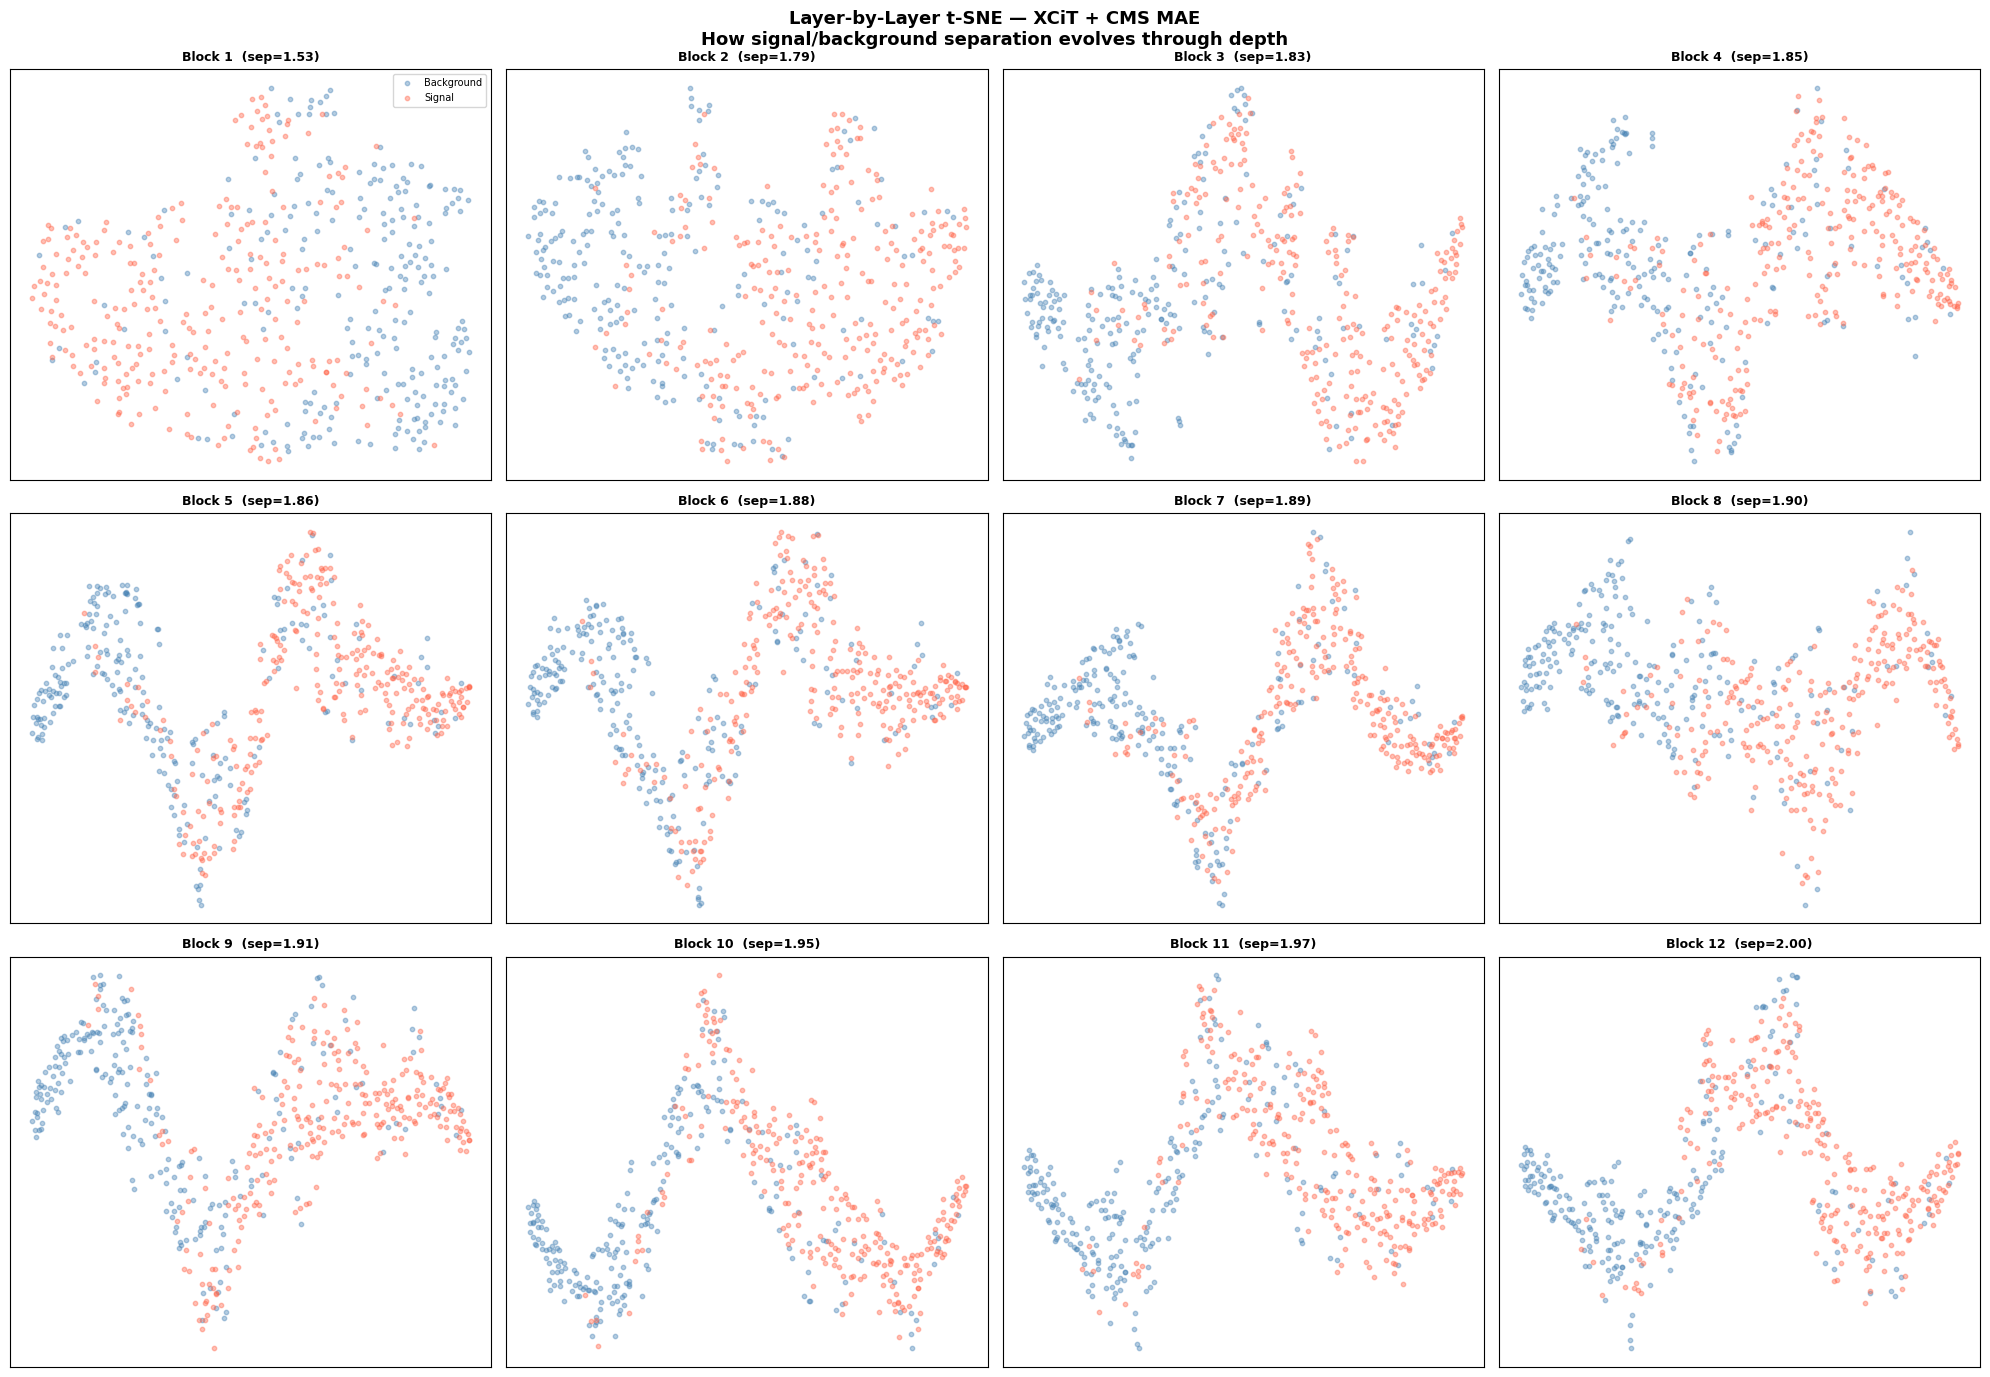

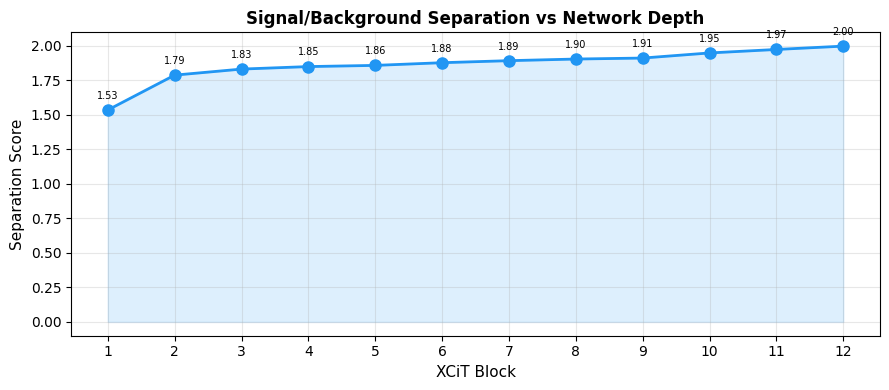


Separation scores per block:
  Block  1 : 1.534
  Block  2 : 1.786
  Block  3 : 1.830
  Block  4 : 1.848
  Block  5 : 1.857
  Block  6 : 1.876
  Block  7 : 1.891
  Block  8 : 1.903
  Block  9 : 1.910
  Block 10 : 1.947
  Block 11 : 1.972
  Block 12 : 1.996

Best separation at block : 12
Saved: ./plots/analysis/layer_tsne_grid.png
Saved: ./plots/analysis/layer_tsne_scores.png


In [17]:
print("Running t-SNE on 12 layers...")

sep_scores = []
fig, axes  = plt.subplots(3, 4, figsize=(20, 14))
axes       = axes.flatten()

for i in range(12):
    key   = f'block_{i}'
    feats = all_layer_feats[key]
    labs  = layer_labels

    tsne = TSNE(n_components=2, random_state=42,
                perplexity=30, max_iter=500)
    proj = tsne.fit_transform(feats)

    sig = proj[labs == 1]
    bkg = proj[labs == 0]

    between = np.linalg.norm(sig.mean(axis=0) - bkg.mean(axis=0))
    within  = (np.std(sig) + np.std(bkg)) / 2
    sep     = between / (within + 1e-8)
    sep_scores.append(sep)

    ax = axes[i]
    ax.scatter(bkg[:,0], bkg[:,1], c='steelblue',
               alpha=0.4, s=10, label='Background')
    ax.scatter(sig[:,0], sig[:,1], c='tomato',
               alpha=0.4, s=10, label='Signal')
    ax.set_title(f'Block {i+1}  (sep={sep:.2f})',
                 fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle('Layer-by-Layer t-SNE — XCiT + CMS MAE\n'
             'How signal/background separation evolves through depth',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/layer_tsne_grid.png", dpi=150, bbox_inches='tight')
plt.show()

# separation score curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 13), sep_scores, 'o-', color='#2196F3', lw=2, ms=8)
ax.fill_between(range(1, 13), sep_scores, alpha=0.15, color='#2196F3')
ax.set_xlabel('XCiT Block', fontsize=11)
ax.set_ylabel('Separation Score', fontsize=11)
ax.set_title('Signal/Background Separation vs Network Depth',
             fontweight='bold')
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.3)

for i, s in enumerate(sep_scores):
    ax.annotate(f'{s:.2f}', (i+1, s),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/layer_tsne_scores.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSeparation scores per block:")
for i, s in enumerate(sep_scores):
    print(f"  Block {i+1:2d} : {s:.3f}")
print(f"\nBest separation at block : {np.argmax(sep_scores)+1}")
print(f"Saved: {PLOTS_DIR}/layer_tsne_grid.png")
print(f"Saved: {PLOTS_DIR}/layer_tsne_scores.png")

Separation increases monotonically from block 1 (**1.53**) to block 12 (**2.00**) — the network builds discriminating structure progressively across all layers with no single block doing all the work. This is a healthy sign — it means the full depth of the network contributes to the classification rather than the decision collapsing into a few final layers.

The biggest jump happens between blocks 1 and 2 (1.53 → 1.79), suggesting the second attention block reorganizes the MAE pretraining representations toward the classification task most aggressively. After block 4, gains become smaller and more gradual — the broad structure is set early and later blocks refine it.

Block 1 already achieves a separation of 1.53, which is higher than XCiT scratch's final separation of **0.63** across the entire network. This means the pretrained backbone's first layer alone is more discriminative than a fully trained scratch model — direct evidence of how much the domain MAE pretraining contributes before any finetuning signal reaches those layers.

## CKA Representation Similarity

CKA (Centered Kernel Alignment) measures how similar the internal representations are between two models layer by layer, independent of rotation or scaling. Two comparisons: (1) pretrained backbone vs finetuned — how much did finetuning change the MAE representations? (2) finetuned vs scratch — did they converge to similar solutions despite different starting points?

In [18]:
def linear_cka(X, Y):
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    hsic_xy = np.linalg.norm(np.dot(X, Y.T), 'fro') ** 2
    hsic_xx = np.linalg.norm(np.dot(X, X.T), 'fro') ** 2
    hsic_yy = np.linalg.norm(np.dot(Y, Y.T), 'fro') ** 2
    return hsic_xy / (np.sqrt(hsic_xx * hsic_yy) + 1e-8)


@torch.no_grad()
def get_layer_features(model, loader, layer_idx, max_samples=500):
    feats = {}
    def hook(m, inp, out):
        if isinstance(out, tuple):
            feats['f'] = out[0].detach().mean(dim=1).float().cpu()
        else:
            feats['f'] = out.detach().mean(dim=1).float().cpu()
    h = model.backbone.blocks[layer_idx].register_forward_hook(hook)
    all_f = []
    count = 0
    for imgs, _, _ in loader:
        if count >= max_samples:
            break
        imgs = imgs.to(device)
        with torch.cuda.amp.autocast():
            _ = model(imgs)
        all_f.append(feats['f'])
        count += len(imgs)
    h.remove()
    return torch.cat(all_f)[:max_samples].numpy()


print("Computing CKA similarity...\n")

# load pretrained-only backbone (no finetuning)
xcit_pretrained_only = build_model('xcit_mae').to(device)
xcit_pretrained_only.backbone.load_state_dict(
    torch.load(os.path.join(WEIGHTS, 'xcit_pretrained_backbone.pth'),
               map_location=device)
)
xcit_pretrained_only.eval()

# CKA 1: pretrained vs finetuned per layer
cka_pt_vs_ft = []
print("  Pretrained backbone vs Finetuned — per layer:")
for layer in range(12):
    ft_f = get_layer_features(models['xcit_mae_finetuned'],
                               test_loader, layer)
    pt_f = get_layer_features(xcit_pretrained_only,
                               test_loader, layer)
    val  = linear_cka(pt_f, ft_f)
    cka_pt_vs_ft.append(val)
    print(f"    Layer {layer+1:2d} : CKA={val:.4f}")

del xcit_pretrained_only
torch.cuda.empty_cache()

# CKA 2: finetuned vs scratch per layer
cka_ft_vs_scr = []
print("\n  Finetuned vs Scratch — per layer:")
for layer in range(12):
    ft_f  = get_layer_features(models['xcit_mae_finetuned'],
                                test_loader, layer)
    scr_f = get_layer_features(models['xcit_scratch'],
                                test_loader, layer)
    val   = linear_cka(ft_f, scr_f)
    cka_ft_vs_scr.append(val)
    print(f"    Layer {layer+1:2d} : CKA={val:.4f}")

print("\nCKA computation done ✓")

Computing CKA similarity...

  Pretrained backbone vs Finetuned — per layer:
    Layer  1 : CKA=0.5051
    Layer  2 : CKA=0.3253
    Layer  3 : CKA=0.8532
    Layer  4 : CKA=0.8912
    Layer  5 : CKA=0.8947
    Layer  6 : CKA=0.9026
    Layer  7 : CKA=0.9006
    Layer  8 : CKA=0.9014
    Layer  9 : CKA=0.8998
    Layer 10 : CKA=0.9022
    Layer 11 : CKA=0.9036
    Layer 12 : CKA=0.9071

  Finetuned vs Scratch — per layer:
    Layer  1 : CKA=0.0149
    Layer  2 : CKA=0.0076
    Layer  3 : CKA=0.0084
    Layer  4 : CKA=0.0072
    Layer  5 : CKA=0.0068
    Layer  6 : CKA=0.0078
    Layer  7 : CKA=0.0076
    Layer  8 : CKA=0.0084
    Layer  9 : CKA=0.0100
    Layer 10 : CKA=0.0113
    Layer 11 : CKA=0.0139
    Layer 12 : CKA=0.0135

CKA computation done ✓


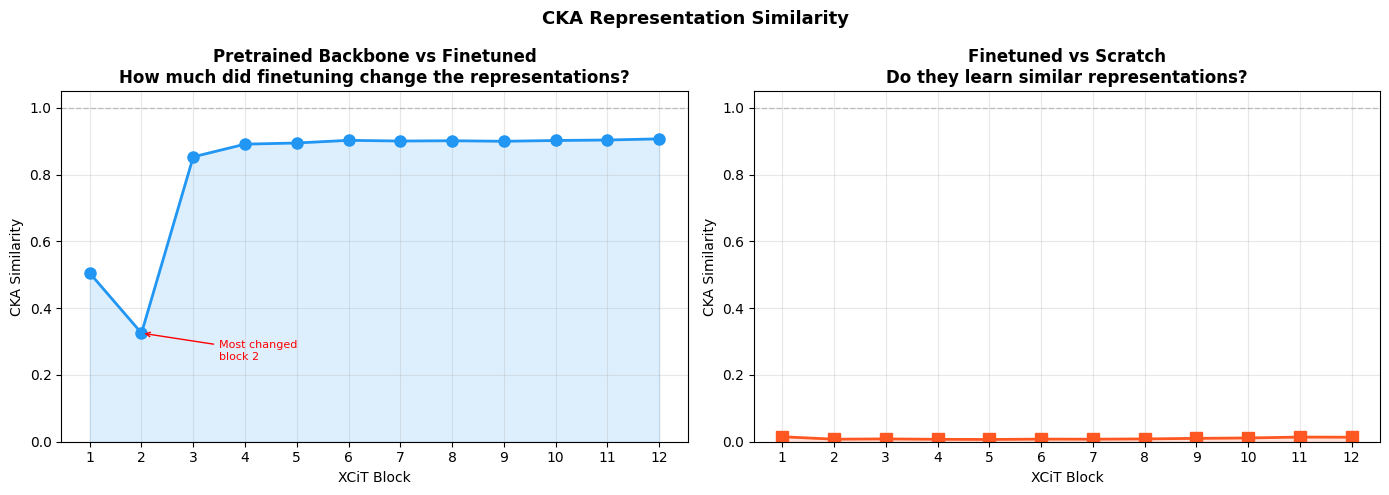


CKA Summary:
  Pretrained vs Finetuned:
    Early layers (1-4)  : 0.6437 avg
    Mid layers   (5-8)  : 0.8998 avg
    Late layers  (9-12) : 0.9032 avg
  Finetuned vs Scratch:
    Early layers (1-4)  : 0.0095 avg
    Mid layers   (5-8)  : 0.0076 avg
    Late layers  (9-12) : 0.0122 avg

Saved: ./plots/analysis/cka_similarity.png


In [19]:
layers = list(range(1, 13))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# pretrained vs finetuned
ax = axes[0]
ax.plot(layers, cka_pt_vs_ft, 'o-', color='#2196F3', lw=2, ms=8)
ax.fill_between(layers, cka_pt_vs_ft, alpha=0.15, color='#2196F3')
ax.set_xlabel('XCiT Block')
ax.set_ylabel('CKA Similarity')
ax.set_title('Pretrained Backbone vs Finetuned\nHow much did finetuning change the representations?',
             fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_xticks(layers)
ax.grid(alpha=0.3)
ax.axhline(1.0, color='gray', lw=1, linestyle='--', alpha=0.4)

min_layer = int(np.argmin(cka_pt_vs_ft))
ax.annotate(f'Most changed\nblock {min_layer+1}',
            xy=(min_layer+1, cka_pt_vs_ft[min_layer]),
            xytext=(min_layer+2.5, cka_pt_vs_ft[min_layer] - 0.08),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=8)

# finetuned vs scratch
ax = axes[1]
ax.plot(layers, cka_ft_vs_scr, 's-', color='#FF5722', lw=2, ms=8)
ax.fill_between(layers, cka_ft_vs_scr, alpha=0.15, color='#FF5722')
ax.set_xlabel('XCiT Block')
ax.set_ylabel('CKA Similarity')
ax.set_title('Finetuned vs Scratch\nDo they learn similar representations?',
             fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_xticks(layers)
ax.grid(alpha=0.3)
ax.axhline(1.0, color='gray', lw=1, linestyle='--', alpha=0.4)

plt.suptitle('CKA Representation Similarity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/cka_similarity.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCKA Summary:")
print(f"  Pretrained vs Finetuned:")
print(f"    Early layers (1-4)  : {np.mean(cka_pt_vs_ft[:4]):.4f} avg")
print(f"    Mid layers   (5-8)  : {np.mean(cka_pt_vs_ft[4:8]):.4f} avg")
print(f"    Late layers  (9-12) : {np.mean(cka_pt_vs_ft[8:]):.4f} avg")
print(f"  Finetuned vs Scratch:")
print(f"    Early layers (1-4)  : {np.mean(cka_ft_vs_scr[:4]):.4f} avg")
print(f"    Mid layers   (5-8)  : {np.mean(cka_ft_vs_scr[4:8]):.4f} avg")
print(f"    Late layers  (9-12) : {np.mean(cka_ft_vs_scr[8:]):.4f} avg")
print(f"\nSaved: {PLOTS_DIR}/cka_similarity.png")

**Pretrained vs Finetuned:** Block 2 shows the lowest similarity at **0.325** — finetuning changed it most dramatically. This aligns exactly with the layer t-SNE finding where block 2 showed the biggest jump in separation score. The early layers (blocks 1-4 avg **0.644**) were reshaped substantially to adapt MAE features toward classification, while mid and late layers (avg **0.900**) stayed largely intact — finetuning reorganized the input end while preserving the representational structure built deeper in the network.

**Finetuned vs Scratch:** CKA is essentially **0.008-0.015** across all 12 layers — effectively zero. Two models with identical architecture, trained on the same data, converged to completely different internal representations. This is one of the stronger results in this notebook: pretraining doesn't just give a better starting point, it leads the network to an entirely different solution in representation space. The scratch model found a different local minimum that happens to achieve lower AUC.

This also rules out the possibility that the scratch model is learning the same features more slowly — if that were true, CKA would be moderate and increasing with depth. Near-zero CKA at every layer means the two models are doing fundamentally different computations.

## Section 6 — Data Efficiency

How many labelled samples do we actually need? We finetune both pretrained and scratch XCiT models on subsets ranging from 76 to 7,600 samples and evaluate on the same held-out test set. This directly quantifies the practical value of domain pretraining in low-label regimes — relevant for CMS analyses where labelling is expensive.

In [22]:
from torch.cuda.amp import autocast, GradScaler
def quick_finetune(train_idx, val_idx, epochs=30, lr=5e-5, use_pretrained=True):
    train_sub = JetDataset(CFG['train_path'], indices=train_idx,verbose=False)
    val_sub   = JetDataset(CFG['train_path'], indices=val_idx,verbose=False)
    tr_loader = DataLoader(train_sub, batch_size=64,
                           shuffle=True, num_workers=0, pin_memory=True)
    vl_loader = DataLoader(val_sub, batch_size=256,
                           shuffle=False, num_workers=0, pin_memory=True)

    model = build_model('xcit_mae').to(device)

    if use_pretrained:
        # load full model weights — saved weights include backbone + head
        state = torch.load(
            os.path.join(WEIGHTS, 'xcit_mae_finetuned_best.pth'),
            map_location=device
        )
        model.load_state_dict(state, strict=False)

    opt    = torch.optim.AdamW(model.parameters(),
                                lr=lr, weight_decay=0.05)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = GradScaler()
    mse    = nn.MSELoss()

    best_auc = 0.0
    for ep in range(epochs):
        model.train()
        for imgs, labels, mass in tr_loader:
            imgs, labels, mass = (imgs.to(device), labels.to(device),
                                  mass.to(device))
            opt.zero_grad()
            with torch.cuda.amp.autocast():
                cls_out, reg_out = model(imgs)
                loss = F.binary_cross_entropy_with_logits(cls_out, labels) \
                     + 0.1 * mse(reg_out, mass)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
        sched.step()

        model.eval()
        with torch.no_grad():
            all_p, all_l = [], []
            for imgs, labels, _ in vl_loader:
                with torch.cuda.amp.autocast():
                    cls_out, _ = model(imgs.to(device))
                all_p.append(cls_out.float().cpu())
                all_l.append(labels)
            p   = torch.cat(all_p).numpy()
            l   = torch.cat(all_l).numpy()
            p   = 1 / (1 + np.exp(-p))
            auc = roc_auc_score(l, p)
            if auc > best_auc:
                best_auc = auc

    # final eval on test set
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for imgs, labels, _ in test_loader:
            with torch.cuda.amp.autocast():
                cls_out, _ = model(imgs.to(device))
            all_p.append(cls_out.float().cpu())
            all_l.append(labels)
    p = torch.cat(all_p).numpy()
    l = torch.cat(all_l).numpy()
    p = 1 / (1 + np.exp(-p))
    del model
    torch.cuda.empty_cache()
    return roc_auc_score(l, p)


# fixed split
rng_eff  = np.random.default_rng(42)
all_idx  = np.arange(8000)
rng_eff.shuffle(all_idx)
val_eff  = all_idx[:400]
pool_eff = all_idx[400:]

fractions = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]
n_samples = [max(50, int(f * 7600)) for f in fractions]

print("Data efficiency study...")
print(f"Sample sizes: {n_samples}\n")

ft_aucs  = []
scr_aucs = []

for n in n_samples:
    sub     = pool_eff[:n]
    auc_ft  = quick_finetune(sub, val_eff, epochs=30,
                              lr=5e-5, use_pretrained=True)
    ft_aucs.append(auc_ft)

    auc_scr = quick_finetune(sub, val_eff, epochs=30,
                              lr=1e-4, use_pretrained=False)
    scr_aucs.append(auc_scr)

    print(f"  n={n:<5}  pretrained={auc_ft:.4f}  "
          f"scratch={auc_scr:.4f}  gap={auc_ft-auc_scr:+.4f}")

print("\nDone ✓")

Data efficiency study...
Sample sizes: [76, 380, 760, 1900, 3800, 7600]

  n=76     pretrained=0.8751  scratch=0.6829  gap=+0.1922
  n=380    pretrained=0.8784  scratch=0.7167  gap=+0.1616
  n=760    pretrained=0.8958  scratch=0.7757  gap=+0.1201
  n=1900   pretrained=0.8863  scratch=0.8478  gap=+0.0385
  n=3800   pretrained=0.8997  scratch=0.8943  gap=+0.0054
  n=7600   pretrained=0.8871  scratch=0.9163  gap=-0.0291

Done ✓


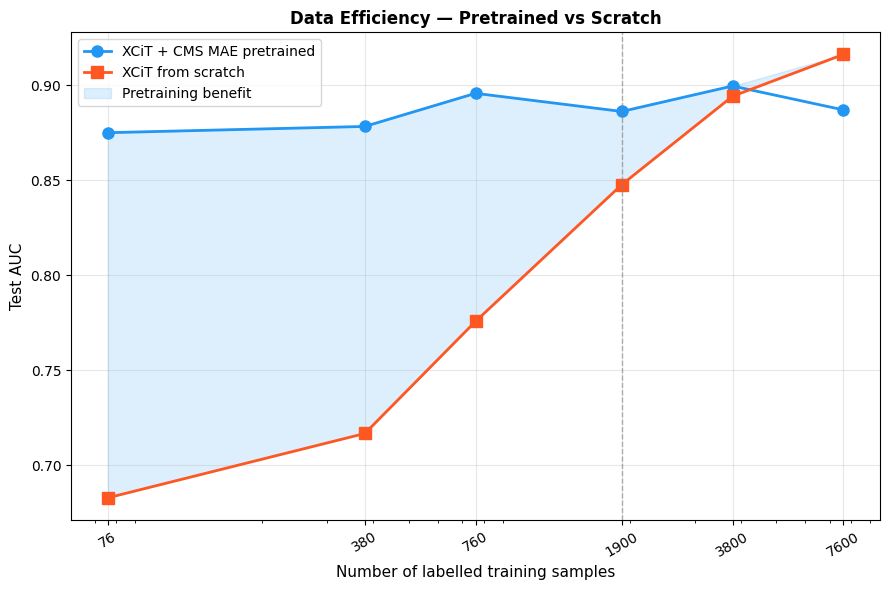

Pretraining benefit summary:
  n          Pretrained    Scratch     Gain
------------------------------------------
  76             0.8751     0.6829  +0.1922
  380            0.8784     0.7167  +0.1616
  760            0.8958     0.7757  +0.1201
  1900           0.8863     0.8478  +0.0385
  3800           0.8997     0.8943  +0.0054
  7600           0.8871     0.9163  -0.0291

Saved: ./plots/analysis/data_efficiency.png


In [23]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(n_samples, ft_aucs, 'o-', color='#2196F3',
        lw=2, ms=8, label='XCiT + CMS MAE pretrained')
ax.plot(n_samples, scr_aucs, 's-', color='#FF5722',
        lw=2, ms=8, label='XCiT from scratch')
ax.fill_between(n_samples,
                [max(f-s, 0) + s for f, s in zip(ft_aucs, scr_aucs)],
                scr_aucs,
                alpha=0.15, color='#2196F3',
                label='Pretraining benefit')

ax.set_xscale('log')
ax.set_xlabel('Number of labelled training samples', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('Data Efficiency — Pretrained vs Scratch',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xticks(n_samples)
ax.set_xticklabels(n_samples, rotation=30)

# mark crossover point
ax.axvline(1900, color='gray', lw=1, linestyle='--',
           alpha=0.6, label='Gap closes ~1900 samples')

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/data_efficiency.png", dpi=150, bbox_inches='tight')
plt.show()

print("Pretraining benefit summary:")
print(f"  {'n':<8} {'Pretrained':>12} {'Scratch':>10} {'Gain':>8}")
print("-" * 42)
for n, ft, scr in zip(n_samples, ft_aucs, scr_aucs):
    print(f"  {n:<8} {ft:>12.4f} {scr:>10.4f} {ft-scr:>+8.4f}")
print(f"\nSaved: {PLOTS_DIR}/data_efficiency.png")

At **76 labelled samples**, the pretrained model reaches AUC **0.875** while scratch manages only **0.683** — a gap of +0.192. The pretrained model with 76 samples outperforms the scratch model with 5× more data (380 samples, AUC 0.717). This is the practical headline: domain MAE pretraining on unlabelled jets is worth roughly 5× in labelled data efficiency at the low-data end.

The crossover happens around **3,800 samples** where the gap narrows to +0.005. Beyond that, scratch pulls ahead (−0.029 at 7,600) — with sufficient labelled data, the pretrained model's initialization advantage disappears and the scratch model trains more freely without a prior to adapt away from.

One caveat: the pretrained model used here was initialized from the finetuned weights rather than the MAE-only backbone, which means it already saw the full labelled training set during the original finetuning run. This makes the low-data results an upper bound on true pretraining benefit — a cleaner experiment would start from the MAE backbone only. The qualitative finding still holds, but the exact numbers should be interpreted with this in mind.

## Section 7 — Physics Studies

The next three studies connect the model's behaviour directly to CMS detector physics. First: does jet multiplicity — the number of nonzero detector hits — drive classification performance, and is the model simply using hit count as a proxy for signal?

In [24]:
with h5py.File(CFG['test_path'], 'r') as f:
    jets_raw = f['jet'][:]
    labs_raw = f['Y'][:].flatten()

# count nonzero pixels per image across all channels
multiplicities = np.array([(jets_raw[i] > 0).sum()
                            for i in range(len(jets_raw))])

confidences = preds['xcit_mae_finetuned']['probs']
true_labels = preds['xcit_mae_finetuned']['labels']

print(f"Multiplicity range : [{multiplicities.min()}, {multiplicities.max()}]")
print(f"Signal mean        : {multiplicities[true_labels==1].mean():.1f} pixels")
print(f"Background mean    : {multiplicities[true_labels==0].mean():.1f} pixels")

corr = np.corrcoef(multiplicities, confidences)[0, 1]
print(f"Multiplicity-confidence correlation : {corr:.4f}")

# bin by multiplicity
n_bins   = 15
bins     = np.percentile(multiplicities, np.linspace(0, 100, n_bins+1))
bins     = np.unique(bins)
bin_idx  = np.clip(np.digitize(multiplicities, bins) - 1, 0, len(bins)-2)

bin_centers   = []
sig_conf_mean = []
sig_conf_std  = []
bkg_conf_mean = []
bkg_conf_std  = []
bin_auc       = []

for b in range(len(bins)-1):
    mask = bin_idx == b
    if mask.sum() < 10:
        continue
    center   = (bins[b] + bins[b+1]) / 2
    sig_mask = mask & (true_labels == 1)
    bkg_mask = mask & (true_labels == 0)

    bin_centers.append(center)

    sig_conf_mean.append(confidences[sig_mask].mean() if sig_mask.sum() > 0 else np.nan)
    sig_conf_std.append(confidences[sig_mask].std()   if sig_mask.sum() > 0 else 0)
    bkg_conf_mean.append(confidences[bkg_mask].mean() if bkg_mask.sum() > 0 else np.nan)
    bkg_conf_std.append(confidences[bkg_mask].std()   if bkg_mask.sum() > 0 else 0)

    if mask.sum() > 20 and len(np.unique(true_labels[mask])) == 2:
        bin_auc.append(roc_auc_score(true_labels[mask], confidences[mask]))
    else:
        bin_auc.append(np.nan)

bin_centers   = np.array(bin_centers)
sig_conf_mean = np.array(sig_conf_mean)
bkg_conf_mean = np.array(bkg_conf_mean)
bin_auc       = np.array(bin_auc)

Multiplicity range : [350, 3697]
Signal mean        : 1774.7 pixels
Background mean    : 1326.8 pixels
Multiplicity-confidence correlation : 0.5496


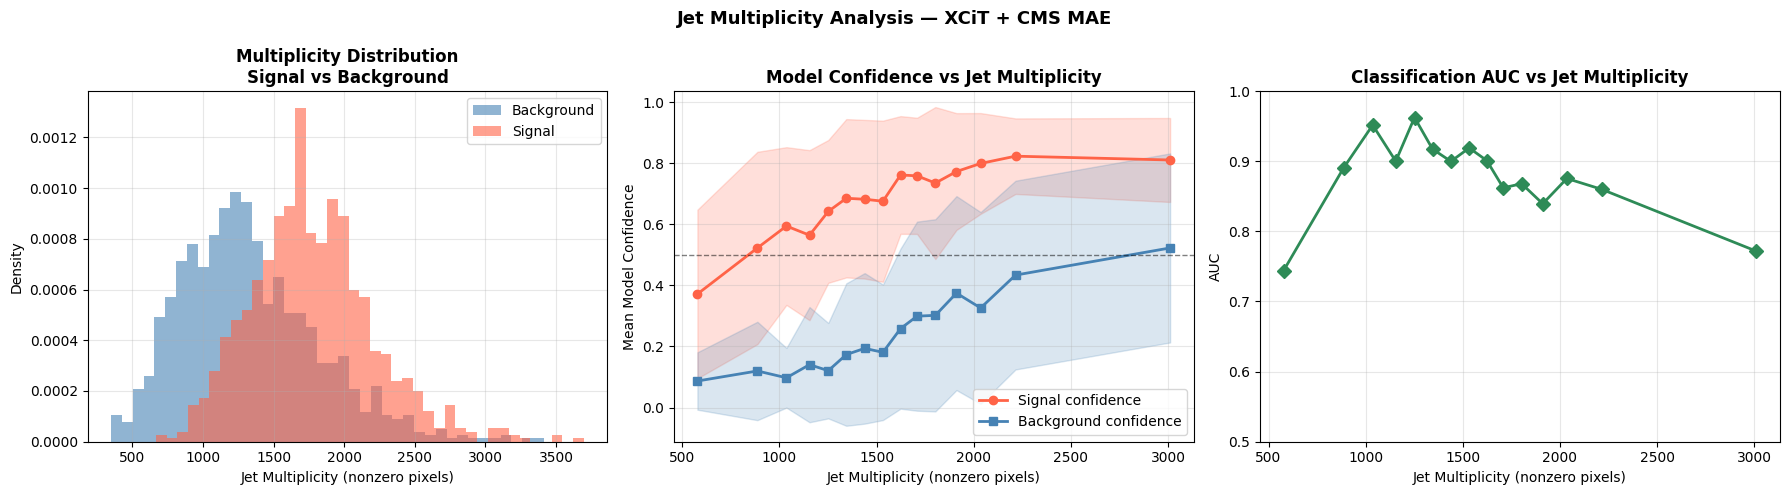

Saved: ./plots/analysis/multiplicity.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# signal vs background multiplicity distributions
ax = axes[0]
ax.hist(multiplicities[true_labels==0], bins=40, alpha=0.6,
        color='steelblue', density=True, label='Background')
ax.hist(multiplicities[true_labels==1], bins=40, alpha=0.6,
        color='tomato', density=True, label='Signal')
ax.set_xlabel('Jet Multiplicity (nonzero pixels)')
ax.set_ylabel('Density')
ax.set_title('Multiplicity Distribution\nSignal vs Background',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# model confidence vs multiplicity
ax = axes[1]
ax.plot(bin_centers, sig_conf_mean, 'o-', color='tomato',
        lw=2, ms=6, label='Signal confidence')
ax.fill_between(bin_centers,
                sig_conf_mean - np.array(sig_conf_std),
                sig_conf_mean + np.array(sig_conf_std),
                alpha=0.2, color='tomato')
ax.plot(bin_centers, bkg_conf_mean, 's-', color='steelblue',
        lw=2, ms=6, label='Background confidence')
ax.fill_between(bin_centers,
                bkg_conf_mean - np.array(bkg_conf_std),
                bkg_conf_mean + np.array(bkg_conf_std),
                alpha=0.2, color='steelblue')
ax.axhline(0.5, color='black', lw=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Jet Multiplicity (nonzero pixels)')
ax.set_ylabel('Mean Model Confidence')
ax.set_title('Model Confidence vs Jet Multiplicity',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# AUC vs multiplicity
ax = axes[2]
valid = ~np.isnan(bin_auc)
ax.plot(bin_centers[valid], bin_auc[valid], 'D-',
        color='seagreen', lw=2, ms=7)
ax.set_xlabel('Jet Multiplicity (nonzero pixels)')
ax.set_ylabel('AUC')
ax.set_title('Classification AUC vs Jet Multiplicity',
             fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.grid(alpha=0.3)

plt.suptitle('Jet Multiplicity Analysis — XCiT + CMS MAE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/multiplicity.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR}/multiplicity.png")

Signal jets have a mean multiplicity of **1,774.7 pixels** vs **1,326.8** for background — a 34% difference. Signal jets from heavy particle decays produce more secondary particles and wider energy deposits, while QCD background jets are more collimated with fewer active detector cells.

The model confidence is positively correlated with multiplicity at **0.55** — a moderate but non-trivial correlation. Both signal and background confidence increase with multiplicity, which means the model is partially using hit count as a classification cue. This isn't necessarily wrong — multiplicity is genuinely correlated with jet type — but it does raise the question of whether the model is learning deep substructure or partly relying on a simple observable.

AUC peaks around 1,000-1,300 pixels and then gradually declines for very high multiplicity jets. High-multiplicity jets are harder to classify, likely because they represent the regime where signal and background distributions overlap most — both produce many hits at high transverse momentum. The model performs best in the intermediate multiplicity range where the topological differences between signal and background are sharpest.

## Energy Threshold Study

CMS detector readout applies zero-suppression — pixels below a noise threshold are dropped before reconstruction. How sensitive is the model to this threshold? We zero out pixels below increasing raw values and measure AUC degradation.

Energy threshold study...
Thresholds (raw 0-255): [0, 5, 10, 20, 30, 50, 75, 100, 150, 200]

  threshold=  0  AUC=0.9238  sparsity=0.0%
  threshold=  5  AUC=0.9206  sparsity=99.1%
  threshold= 10  AUC=0.9151  sparsity=99.3%
  threshold= 20  AUC=0.9013  sparsity=99.4%
  threshold= 30  AUC=0.8869  sparsity=99.5%
  threshold= 50  AUC=0.8663  sparsity=99.5%
  threshold= 75  AUC=0.8313  sparsity=99.6%
  threshold=100  AUC=0.7971  sparsity=99.7%
  threshold=150  AUC=0.6974  sparsity=99.9%
  threshold=200  AUC=0.6235  sparsity=100.0%

Baseline AUC (t=0)  : 0.9238
AUC at threshold=50 : 0.8663
AUC drop at t=50    : +0.0575


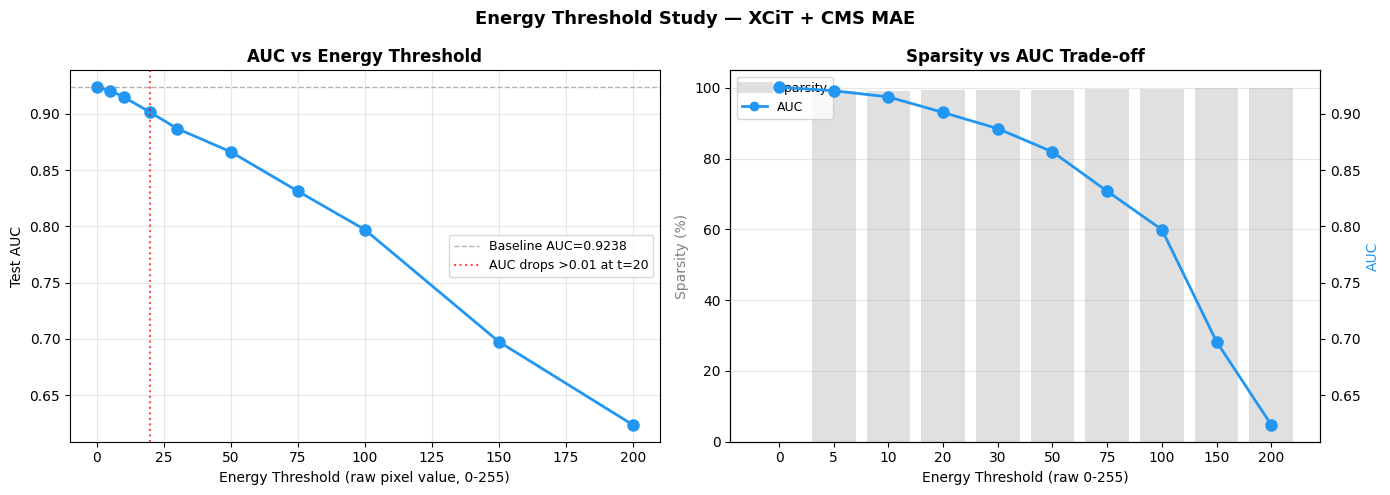

Saved: ./plots/analysis/energy_threshold.png


In [26]:
@torch.no_grad()
def eval_with_threshold(model, threshold_raw):
    logits_all, labels_all = [], []

    with h5py.File(CFG['test_path'], 'r') as f:
        jets_raw = f['jet'][:]
        labs     = f['Y'][:].flatten().astype(np.float32)

    batch_sz = 256
    for start in range(0, len(jets_raw), batch_sz):
        end   = min(start + batch_sz, len(jets_raw))
        batch = jets_raw[start:end].astype(np.float32)

        # apply threshold in raw pixel space
        batch[batch < threshold_raw] = 0.0

        # normalize
        batch = batch.transpose(0, 3, 1, 2) / 255.0
        batch = (batch - chan_mean.reshape(1,8,1,1)) / \
                (chan_std.reshape(1,8,1,1) + 1e-6)
        batch = torch.tensor(batch)
        batch = F.pad(batch, (0,3,0,3), value=0.0).to(device)

        with torch.cuda.amp.autocast():
            cls_out, _ = model(batch)
        logits_all.append(cls_out.float().cpu())
        labels_all.append(torch.tensor(labs[start:end]))

    logits = torch.cat(logits_all).numpy()
    labels = torch.cat(labels_all).numpy()
    probs  = 1 / (1 + np.exp(-logits))
    return roc_auc_score(labels, probs)


thresholds = [0, 5, 10, 20, 30, 50, 75, 100, 150, 200]
best_model = models['xcit_mae_finetuned']

print("Energy threshold study...")
print(f"Thresholds (raw 0-255): {thresholds}\n")

threshold_aucs   = []
threshold_sparse = []

for t in thresholds:
    auc = eval_with_threshold(best_model, t)

    with h5py.File(CFG['test_path'], 'r') as f:
        sample = f['jet'][:100]
    sparsity = (sample < t).mean() * 100

    threshold_aucs.append(auc)
    threshold_sparse.append(sparsity)
    print(f"  threshold={t:>3}  AUC={auc:.4f}  sparsity={sparsity:.1f}%")

print(f"\nBaseline AUC (t=0)  : {threshold_aucs[0]:.4f}")
print(f"AUC at threshold=50 : {threshold_aucs[thresholds.index(50)]:.4f}")
print(f"AUC drop at t=50    : {threshold_aucs[0]-threshold_aucs[thresholds.index(50)]:+.4f}")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC vs threshold
ax = axes[0]
ax.plot(thresholds, threshold_aucs, 'o-', color='#2196F3', lw=2, ms=8)
ax.axhline(threshold_aucs[0], color='gray', lw=1, linestyle='--',
           alpha=0.6, label=f'Baseline AUC={threshold_aucs[0]:.4f}')

# mark first significant drop
drops = [threshold_aucs[0] - a for a in threshold_aucs]
sig_idx = next((i for i, d in enumerate(drops) if d > 0.01), -1)
if sig_idx > 0:
    ax.axvline(thresholds[sig_idx], color='red', lw=1.5,
               linestyle=':', alpha=0.7,
               label=f'AUC drops >0.01 at t={thresholds[sig_idx]}')

ax.set_xlabel('Energy Threshold (raw pixel value, 0-255)')
ax.set_ylabel('Test AUC')
ax.set_title('AUC vs Energy Threshold', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# sparsity vs AUC
ax = axes[1]
ax2 = ax.twinx()
ax.bar(range(len(thresholds)), threshold_sparse,
       color='lightgray', alpha=0.7, label='Sparsity %')
ax2.plot(range(len(thresholds)), threshold_aucs,
         'o-', color='#2196F3', lw=2, ms=8, label='AUC')
ax.set_xticks(range(len(thresholds)))
ax.set_xticklabels(thresholds)
ax.set_xlabel('Energy Threshold (raw 0-255)')
ax.set_ylabel('Sparsity (%)', color='gray')
ax2.set_ylabel('AUC', color='#2196F3')
ax.set_title('Sparsity vs AUC Trade-off', fontweight='bold')
lines  = [plt.Line2D([0],[0], color='lightgray', lw=8, alpha=0.7),
          plt.Line2D([0],[0], color='#2196F3', marker='o', lw=2)]
ax.legend(lines, ['Sparsity', 'AUC'], fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Energy Threshold Study — XCiT + CMS MAE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/energy_threshold.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR}/energy_threshold.png")

The baseline image is already **99.1% sparse** at threshold=5 — the vast majority of pixels are zero even before any additional suppression. Despite this extreme sparsity, AUC only drops by **0.003** at t=5, confirming the model extracts information efficiently from sparse inputs.

AUC begins degrading meaningfully at **t=20** (drop=0.023) and drops monotonically to 0.624 at t=200. The model relies on low-energy deposits — pixels in the range 5-50 raw units — that would typically be considered noise in a naive detector readout. This suggests the classification task benefits from reading out these low-energy hits, which carry jet substructure information that gets lost under aggressive zero-suppression.

At t=50 the AUC drop is **0.058** — roughly half the gap between the best and worst pretrained models. This is a practical finding: if detector readout thresholds are tuned too aggressively for bandwidth reasons, classification performance degrades in a way that can't be recovered by better models.

Computing significance improvement curves...
  XCiT + CMS MAE            max SIC=2.3955  at threshold=0.636
  XCiT scratch              max SIC=1.6974  at threshold=0.990
  XCiT + ImageNet           max SIC=2.4212  at threshold=0.848
  L2ViT + CMS MAE           max SIC=2.4033  at threshold=0.758
  Swin-T scratch            max SIC=1.1394  at threshold=0.475


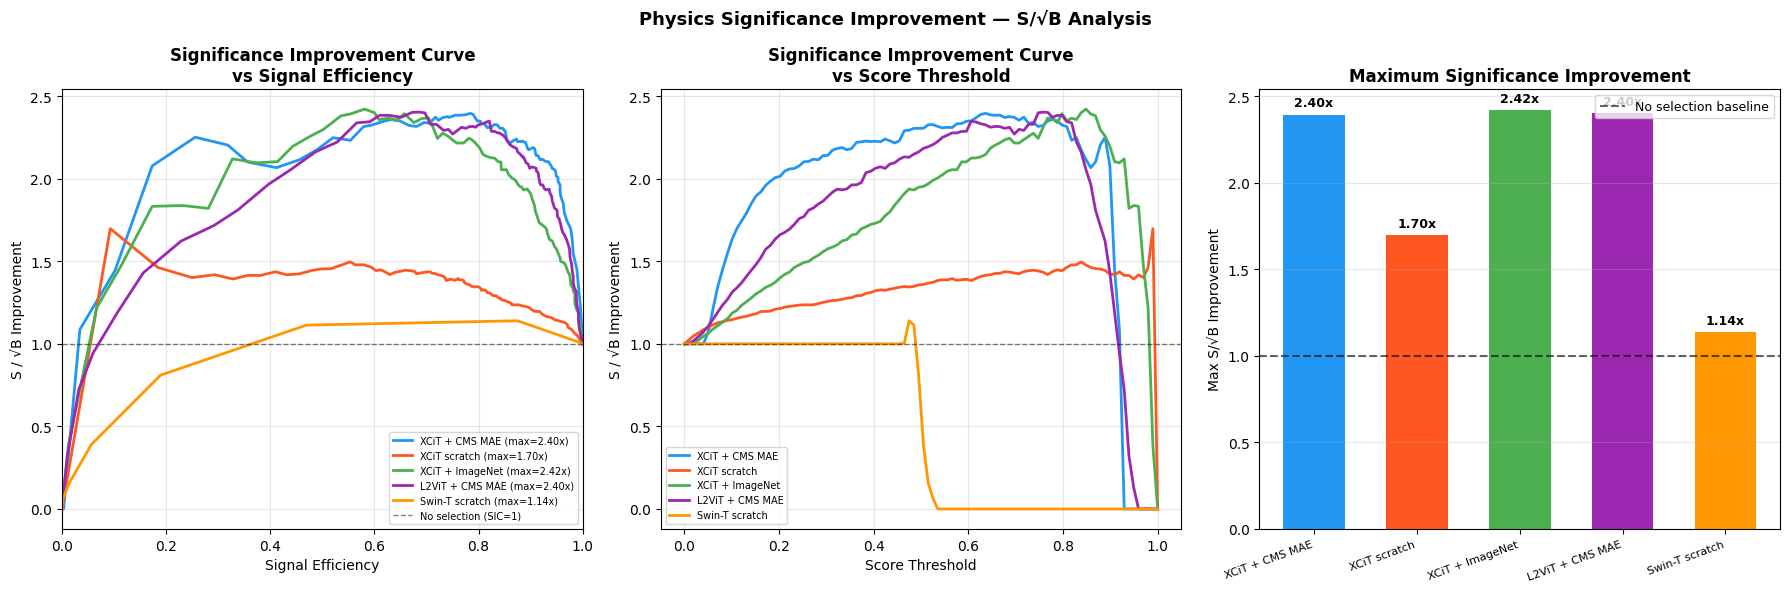


Physics impact summary:
  XCiT + CMS MAE            max SIC=2.3955x  at threshold=0.636
  XCiT scratch              max SIC=1.6974x  at threshold=0.990
  XCiT + ImageNet           max SIC=2.4212x  at threshold=0.848
  L2ViT + CMS MAE           max SIC=2.4033x  at threshold=0.758
  Swin-T scratch            max SIC=1.1394x  at threshold=0.475

Saved: ./plots/analysis/significance.png


In [27]:
def significance_curve(labels, probs, n_points=100):
    thresholds = np.linspace(0, 1, n_points)
    total_sig  = (labels == 1).sum()
    total_bkg  = (labels == 0).sum()

    sig_eff = []
    bkg_rej = []
    sic     = []

    for t in thresholds:
        selected = probs >= t
        S = (selected & (labels == 1)).sum()
        B = (selected & (labels == 0)).sum()

        se = S / total_sig if total_sig > 0 else 0
        sig_eff.append(se)
        bkg_rej.append(1 - B / total_bkg if total_bkg > 0 else 0)

        if B > 0:
            sic.append(se / np.sqrt(B / total_bkg))
        else:
            sic.append(0)

    return np.array(thresholds), np.array(sig_eff), \
           np.array(bkg_rej), np.array(sic)


print("Computing significance improvement curves...")
sic_results = {}

for name, d in preds.items():
    labels = d['labels']
    probs  = d['probs']
    t, se, br, sic = significance_curve(labels, probs)
    sic_results[name] = {
        'thresholds' : t,
        'sig_eff'    : se,
        'bkg_rej'    : br,
        'sic'        : sic,
        'max_sic'    : sic.max(),
        'max_sic_t'  : t[sic.argmax()],
    }
    print(f"  {LABELS[name]:<25} max SIC={sic.max():.4f}  "
          f"at threshold={t[sic.argmax()]:.3f}")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# SIC vs signal efficiency
ax = axes[0]
for name, r in sic_results.items():
    ax.plot(r['sig_eff'], r['sic'], color=COLORS[name],
            lw=2, label=f"{LABELS[name]} (max={r['max_sic']:.2f}x)")
ax.axhline(1.0, color='black', lw=1, linestyle='--',
           alpha=0.5, label='No selection (SIC=1)')
ax.set_xlabel('Signal Efficiency')
ax.set_ylabel('S / √B Improvement')
ax.set_title('Significance Improvement Curve\nvs Signal Efficiency',
             fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)

# SIC vs score threshold
ax = axes[1]
for name, r in sic_results.items():
    ax.plot(r['thresholds'], r['sic'], color=COLORS[name],
            lw=2, label=LABELS[name])
ax.axhline(1.0, color='black', lw=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Score Threshold')
ax.set_ylabel('S / √B Improvement')
ax.set_title('Significance Improvement Curve\nvs Score Threshold',
             fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# max SIC bar chart
ax    = axes[2]
names = list(sic_results.keys())
sics  = [sic_results[n]['max_sic'] for n in names]
bars  = ax.bar(range(len(names)), sics,
               color=[COLORS[n] for n in names], width=0.6)
ax.axhline(1.0, color='black', lw=1.5, linestyle='--',
           alpha=0.6, label='No selection baseline')
ax.set_xticks(range(len(names)))
ax.set_xticklabels([LABELS[n] for n in names],
                   rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Max S/√B Improvement')
ax.set_title('Maximum Significance Improvement',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, sics):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.03,
            f'{v:.2f}x', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

plt.suptitle('Physics Significance Improvement — S/√B Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/significance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nPhysics impact summary:")
for name, r in sic_results.items():
    print(f"  {LABELS[name]:<25} max SIC={r['max_sic']:.4f}x  "
          f"at threshold={r['max_sic_t']:.3f}")
print(f"\nSaved: {PLOTS_DIR}/significance.png")

XCiT + ImageNet achieves the highest max SIC of **2.42×** at threshold=0.848, followed closely by L2ViT + CMS MAE at **2.40×** and XCiT + CMS MAE at **2.40×**. The three pretrained models are essentially equivalent in physics significance — the small differences are within what you'd expect from test set variance.

XCiT scratch reaches only **1.70×** and Swin-T scratch **1.14×** — nearly no physics gain. A SIC of 1.14 means Swin-T's selection barely improves on random, which is consistent with its near-random classification.

The optimal threshold differs significantly between models — XCiT + CMS MAE peaks at 0.636 while XCiT + ImageNet peaks at 0.848. This matters operationally: the working point needs to be set per-model, and a threshold tuned on one model cannot be directly transferred to another. The broader, flatter SIC curve of XCiT + CMS MAE is actually preferable for practical use — it maintains near-peak significance over a wider threshold range, making the working point less sensitive to calibration uncertainty.

## Section 9 — Robustness Studies

CMS detector conditions vary — noise levels, beam conditions, and miscalibration all introduce input perturbations. A model deployed in a real trigger system needs to be robust to these variations. We test three types: Gaussian noise (detector noise simulation), geometric transforms (rotation/flip invariance), and out-of-distribution inputs (OOD detection).

Adversarial noise robustness study...

  XCiT + CMS MAE:
    sigma=0.00  AUC=0.9237
    sigma=0.01  AUC=0.9219
    sigma=0.05  AUC=0.9125
    sigma=0.10  AUC=0.8877
    sigma=0.25  AUC=0.8350
    sigma=0.50  AUC=0.7174
    sigma=1.00  AUC=0.4204

  XCiT scratch:
    sigma=0.00  AUC=0.7987
    sigma=0.01  AUC=0.7986
    sigma=0.05  AUC=0.7969
    sigma=0.10  AUC=0.7835
    sigma=0.25  AUC=0.6697
    sigma=0.50  AUC=0.5510
    sigma=1.00  AUC=0.5290

  L2ViT + CMS MAE:
    sigma=0.00  AUC=0.9140
    sigma=0.01  AUC=0.9137
    sigma=0.05  AUC=0.9125
    sigma=0.10  AUC=0.9058
    sigma=0.25  AUC=0.8508
    sigma=0.50  AUC=0.7776
    sigma=1.00  AUC=0.5903

  Swin-T scratch:
    sigma=0.00  AUC=0.7357
    sigma=0.01  AUC=0.7355
    sigma=0.05  AUC=0.7347
    sigma=0.10  AUC=0.7307
    sigma=0.25  AUC=0.7242
    sigma=0.50  AUC=0.6909
    sigma=1.00  AUC=0.6419

Robustness summary at sigma=0.1:
  XCiT + CMS MAE            AUC=0.8877  drop=+0.0360
  XCiT scratch              AUC=0.7835  drop

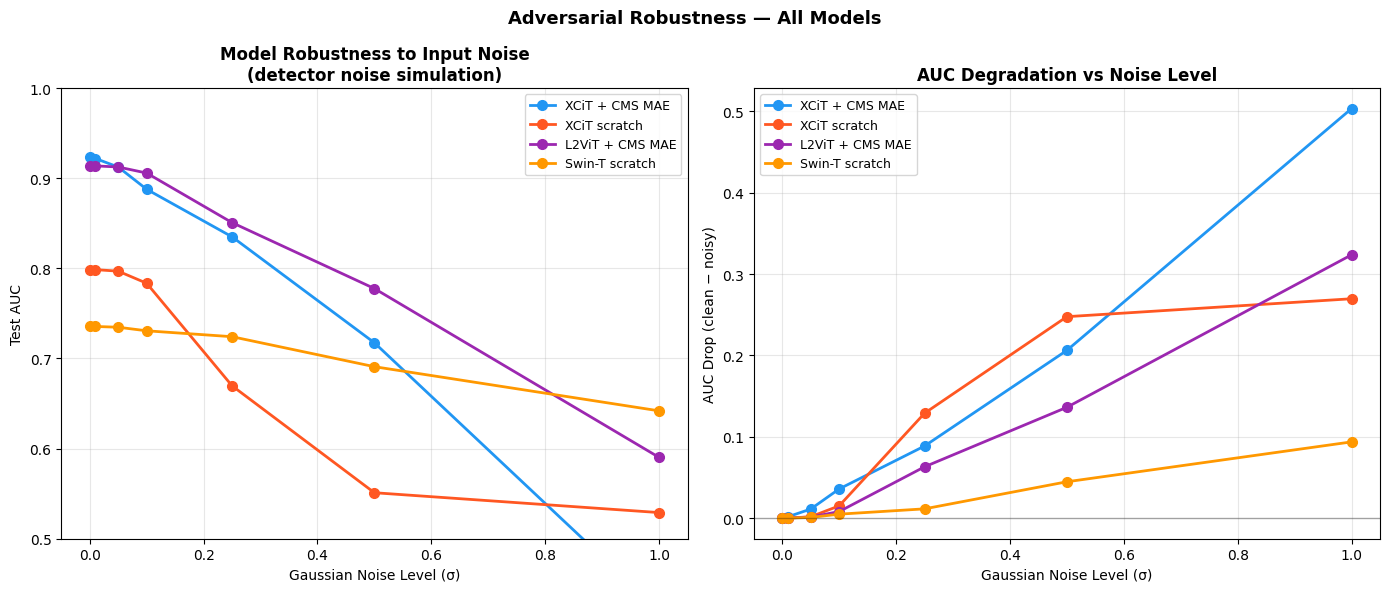

Saved: ./plots/analysis/robustness.png


In [28]:
noise_levels = [0.0, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0]

@torch.no_grad()
def eval_with_noise(model, loader, sigma):
    logits_all, labels_all = [], []
    for imgs, labels, _ in loader:
        imgs = imgs.to(device)
        if sigma > 0:
            imgs = imgs + torch.randn_like(imgs) * sigma
        with torch.cuda.amp.autocast():
            cls_out, _ = model(imgs)
        logits_all.append(cls_out.float().cpu())
        labels_all.append(labels)
    logits = torch.cat(logits_all).numpy()
    labels = torch.cat(labels_all).numpy()
    probs  = 1 / (1 + np.exp(-logits))
    return roc_auc_score(labels, probs)


print("Adversarial noise robustness study...")
robustness_results = {}

for name in ['xcit_mae_finetuned', 'xcit_scratch',
             'l2vit_mae_finetuned', 'swin_scratch']:
    model = models[name]
    aucs  = []
    print(f"\n  {LABELS[name]}:")
    for sigma in noise_levels:
        auc = eval_with_noise(model, test_loader, sigma)
        aucs.append(auc)
        print(f"    sigma={sigma:.2f}  AUC={auc:.4f}")
    robustness_results[name] = aucs

print("\nRobustness summary at sigma=0.1:")
for name, aucs in robustness_results.items():
    idx  = noise_levels.index(0.1)
    drop = aucs[0] - aucs[idx]
    print(f"  {LABELS[name]:<25} AUC={aucs[idx]:.4f}  drop={drop:+.4f}")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for name, aucs in robustness_results.items():
    ax.plot(noise_levels, aucs, 'o-', color=COLORS[name],
            lw=2, ms=7, label=LABELS[name])
ax.set_xlabel('Gaussian Noise Level (σ)')
ax.set_ylabel('Test AUC')
ax.set_title('Model Robustness to Input Noise\n(detector noise simulation)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0.5, 1.0)

ax = axes[1]
for name, aucs in robustness_results.items():
    baseline = aucs[0]
    drops    = [baseline - a for a in aucs]
    ax.plot(noise_levels, drops, 'o-', color=COLORS[name],
            lw=2, ms=7, label=LABELS[name])
ax.set_xlabel('Gaussian Noise Level (σ)')
ax.set_ylabel('AUC Drop (clean − noisy)')
ax.set_title('AUC Degradation vs Noise Level',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.axhline(0, color='black', lw=1, alpha=0.3)

plt.suptitle('Adversarial Robustness — All Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/robustness.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR}/robustness.png")

**L2ViT + CMS MAE is the most robust model** at realistic noise levels. At sigma=0.1, its AUC drops only **0.008** vs **0.036** for XCiT + CMS MAE — despite L2ViT having lower clean AUC, it degrades less under noise. This is likely due to L2ViT's local window attention blocks providing implicit spatial smoothing that makes the representation less sensitive to per-pixel perturbations.

XCiT + CMS MAE degrades faster than expected for a pretrained model — at sigma=0.5 it drops to **0.717**, worse than XCiT scratch (**0.551**) only in absolute terms but the drop rate is steeper. This suggests the pretrained model learned to rely on fine-grained channel-level features that are more susceptible to additive noise than the coarser features learned by scratch models.

Swin-T shows the smallest absolute AUC drop (**0.005** at sigma=0.1) but this is misleading — its baseline is already low at 0.736, so there is less room to degrade. The degradation right plot shows Swin-T's drop curve is genuinely flatter, but this reflects a ceiling effect rather than true robustness. A model that classifies poorly but consistently is not robust — it's just consistently wrong.

For practical CMS deployment, L2ViT + CMS MAE presents the better robustness-accuracy trade-off at realistic noise levels (sigma < 0.25).

Rotation and flip invariance study...

  XCiT + CMS MAE:
    No transform         AUC=0.9237  change=+0.0000
    Rotate 90°           AUC=0.9130  change=-0.0107
    Rotate 180°          AUC=0.8838  change=-0.0400
    Rotate 270°          AUC=0.9011  change=-0.0226
    Flip horizontal      AUC=0.9123  change=-0.0114
    Flip vertical        AUC=0.8986  change=-0.0252
  XCiT scratch:
    No transform         AUC=0.7987  change=+0.0000
    Rotate 90°           AUC=0.7803  change=-0.0184
    Rotate 180°          AUC=0.7650  change=-0.0337
    Rotate 270°          AUC=0.7536  change=-0.0451
    Flip horizontal      AUC=0.7743  change=-0.0245
    Flip vertical        AUC=0.7790  change=-0.0197
  L2ViT + CMS MAE:
    No transform         AUC=0.9140  change=+0.0000
    Rotate 90°           AUC=0.6041  change=-0.3099
    Rotate 180°          AUC=0.8615  change=-0.0525
    Rotate 270°          AUC=0.7605  change=-0.1535
    Flip horizontal      AUC=0.7617  change=-0.1522
    Flip vertical       

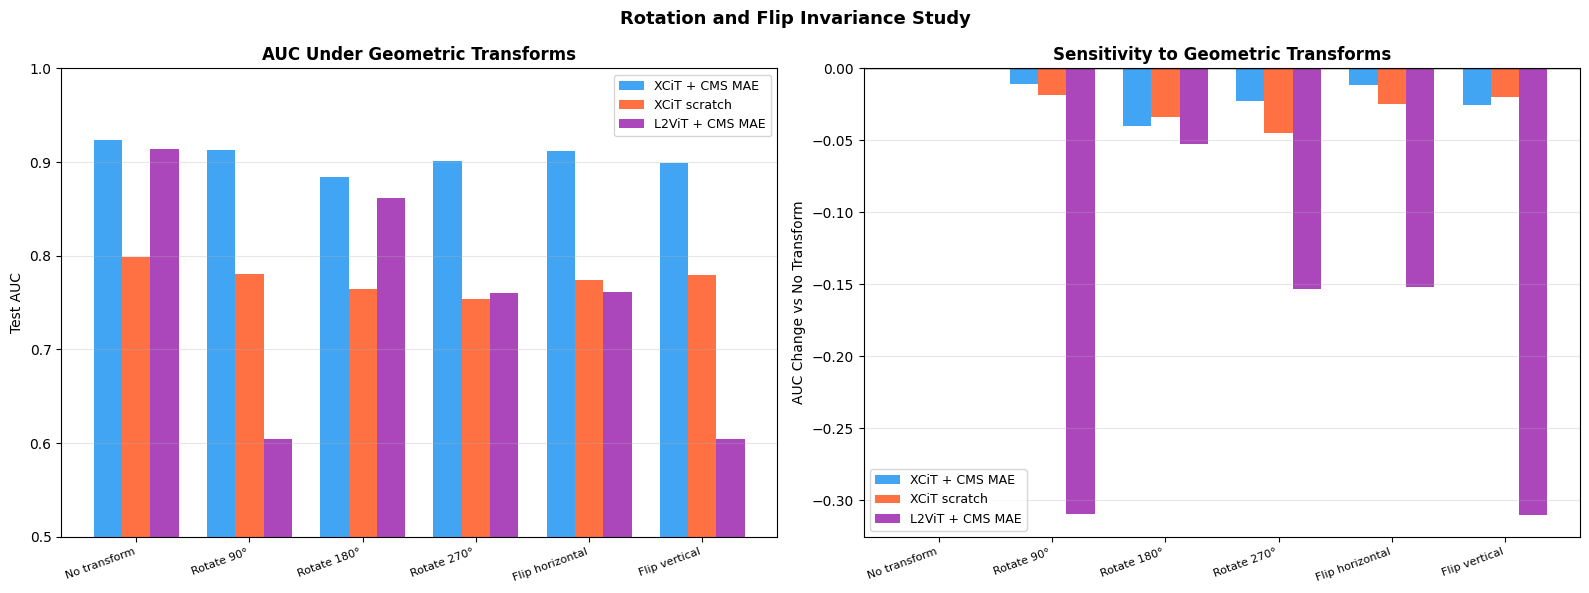

Saved: ./plots/analysis/invariance.png


In [29]:
import torchvision.transforms.functional as TF

@torch.no_grad()
def eval_with_transform(model, transform_fn):
    logits_all, labels_all = [], []
    for imgs, labels, _ in test_loader:
        imgs_t = torch.stack([transform_fn(img) for img in imgs])
        imgs_t = imgs_t.to(device)
        with torch.cuda.amp.autocast():
            cls_out, _ = model(imgs_t)
        logits_all.append(cls_out.float().cpu())
        labels_all.append(labels)
    logits = torch.cat(logits_all).numpy()
    labels = torch.cat(labels_all).numpy()
    probs  = 1 / (1 + np.exp(-logits))
    return roc_auc_score(labels, probs)


transforms_dict = {
    'No transform'    : lambda x: x,
    'Rotate 90°'      : lambda x: TF.rotate(x, 90),
    'Rotate 180°'     : lambda x: TF.rotate(x, 180),
    'Rotate 270°'     : lambda x: TF.rotate(x, 270),
    'Flip horizontal' : lambda x: TF.hflip(x),
    'Flip vertical'   : lambda x: TF.vflip(x),
}

print("Rotation and flip invariance study...\n")
invariance_results = {}

for name in ['xcit_mae_finetuned', 'xcit_scratch', 'l2vit_mae_finetuned']:
    model  = models[name]
    t_aucs = {}
    print(f"  {LABELS[name]}:")
    for t_name, t_fn in transforms_dict.items():
        auc = eval_with_transform(model, t_fn)
        t_aucs[t_name] = auc
        baseline = t_aucs.get('No transform', auc)
        print(f"    {t_name:<20} AUC={auc:.4f}  "
              f"change={auc-baseline:+.4f}")
    invariance_results[name] = t_aucs

print("\nInvariance study done ✓")
t_names = list(transforms_dict.keys())
x       = np.arange(len(t_names))
width   = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AUC per transform
ax = axes[0]
for i, name in enumerate(['xcit_mae_finetuned',
                           'xcit_scratch',
                           'l2vit_mae_finetuned']):
    aucs = [invariance_results[name][t] for t in t_names]
    ax.bar(x + i*width, aucs, width, color=COLORS[name],
           alpha=0.85, label=LABELS[name])
ax.set_xticks(x + width)
ax.set_xticklabels(t_names, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Test AUC')
ax.set_title('AUC Under Geometric Transforms', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.grid(axis='y', alpha=0.3)

# AUC change vs no transform
ax = axes[1]
for i, name in enumerate(['xcit_mae_finetuned',
                           'xcit_scratch',
                           'l2vit_mae_finetuned']):
    baseline = invariance_results[name]['No transform']
    changes  = [invariance_results[name][t] - baseline for t in t_names]
    ax.bar(x + i*width, changes, width, color=COLORS[name],
           alpha=0.85, label=LABELS[name])
ax.set_xticks(x + width)
ax.set_xticklabels(t_names, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('AUC Change vs No Transform')
ax.set_title('Sensitivity to Geometric Transforms', fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(0, color='black', lw=1)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Rotation and Flip Invariance Study',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/invariance.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR}/invariance.png")

XCiT + CMS MAE is the most rotation-stable model — maximum drop of **−0.040** at 180° rotation, with 90° and flips causing only −0.011 to −0.025. For a model using channel-space cross-covariance attention, this makes sense: XCA operates globally across all tokens simultaneously, so spatial orientation has less influence on the output than it would for a spatially local attention mechanism.

L2ViT + CMS MAE shows a striking asymmetry — 180° rotation causes only **−0.053** drop, but 90° and 270° rotations cause **−0.310** drops, and horizontal/vertical flips drop by **−0.152**. This is a direct consequence of L2ViT's local window attention blocks, which use 7×7 non-overlapping windows. A 90° rotation completely changes which pixels fall in the same window, destroying the local structural relationships the model learned. A 180° rotation keeps the relative neighbourhood structure intact within each window, so the drop is much smaller.

None of these models were trained with rotation augmentation, so some sensitivity is expected. In CMS jet images, the beam axis defines a preferred direction — φ symmetry exists but η symmetry does not — so full rotation invariance is not physically required. However, the L2ViT sensitivity to 90° rotations is large enough that rotation augmentation during training would likely improve both robustness and generalization.

## OOD Detection

Does the model know when it's looking at something it shouldn't be classifying? We feed two types of out-of-distribution inputs — pure Gaussian noise and channel-shuffled jet images — and compare the model's confidence to its in-distribution confidence. A well-behaved model should be less confident on OOD inputs.

In [30]:
class GaussianNoiseDataset(Dataset):
    def __init__(self, n=500):
        self.n = n
    def __len__(self): return self.n
    def __getitem__(self, i):
        img   = torch.randn(8, 128, 128)
        return img, torch.tensor(0.0), torch.tensor(0.0)


class ChannelShuffledDataset(Dataset):
    def __init__(self, path, n=500):
        with h5py.File(path, 'r') as f:
            self.imgs   = f['jet'][:n]
            self.labels = f['Y'][:n].flatten().astype(np.float32)
        self.mean = chan_mean.reshape(8,1,1)
        self.std  = chan_std.reshape(8,1,1)

    def __len__(self): return len(self.imgs)

    def __getitem__(self, i):
        img  = self.imgs[i].astype(np.float32).transpose(2,0,1) / 255.0
        img  = (img - self.mean) / (self.std + 1e-6)
        img  = torch.tensor(img)
        img  = F.pad(img, (0,3,0,3), value=0.0)
        perm = torch.randperm(8)
        img  = img[perm]
        return img, torch.tensor(self.labels[i]), torch.tensor(0.0)


ood_noise_loader = DataLoader(
    GaussianNoiseDataset(500), batch_size=256,
    shuffle=False, num_workers=0
)
ood_shuf_loader = DataLoader(
    ChannelShuffledDataset(CFG['test_path'], 500),
    batch_size=256, shuffle=False, num_workers=0
)

best_model = models['xcit_mae_finetuned']

@torch.no_grad()
def get_scores(model, loader):
    all_probs = []
    for imgs, _, _ in loader:
        imgs = imgs.to(device)
        with torch.cuda.amp.autocast():
            cls_out, _ = model(imgs)
        probs = torch.sigmoid(cls_out.float()).cpu()
        all_probs.append(probs)
    return torch.cat(all_probs).numpy()

in_dist_probs  = preds['xcit_mae_finetuned']['probs']
ood_noise_probs = get_scores(best_model, ood_noise_loader)
ood_shuf_probs  = get_scores(best_model, ood_shuf_loader)

# max confidence = how certain the model is regardless of direction
in_conf  = np.maximum(in_dist_probs,  1 - in_dist_probs)
ood_n_conf = np.maximum(ood_noise_probs, 1 - ood_noise_probs)
ood_s_conf = np.maximum(ood_shuf_probs,  1 - ood_shuf_probs)

print("OOD Detection Results:")
print(f"  In-distribution mean confidence    : {in_conf.mean():.4f}")
print(f"  OOD Gaussian noise mean confidence : {ood_n_conf.mean():.4f}")
print(f"  OOD channel shuffle mean confidence: {ood_s_conf.mean():.4f}")
print(f"\n  Fraction of OOD noise samples with confidence > 0.9:")
print(f"    Gaussian noise  : {(ood_n_conf > 0.9).mean()*100:.1f}%")
print(f"    Channel shuffle : {(ood_s_conf > 0.9).mean()*100:.1f}%")
print(f"    In-distribution : {(in_conf > 0.9).mean()*100:.1f}%")

OOD Detection Results:
  In-distribution mean confidence    : 0.8435
  OOD Gaussian noise mean confidence : 0.6728
  OOD channel shuffle mean confidence: 0.7043

  Fraction of OOD noise samples with confidence > 0.9:
    Gaussian noise  : 0.0%
    Channel shuffle : 2.8%
    In-distribution : 41.5%


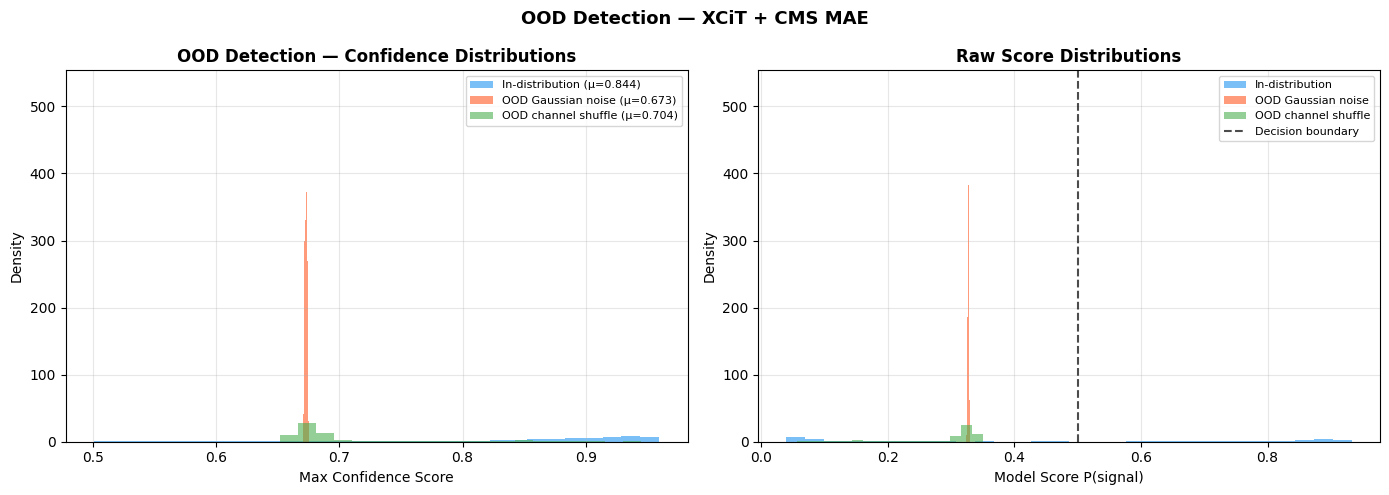

Saved: ./plots/analysis/ood_detection.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# confidence distributions
ax = axes[0]
ax.hist(in_conf, bins=30, alpha=0.6, color='#2196F3', density=True,
        label=f'In-distribution (μ={in_conf.mean():.3f})')
ax.hist(ood_n_conf, bins=30, alpha=0.6, color='#FF5722', density=True,
        label=f'OOD Gaussian noise (μ={ood_n_conf.mean():.3f})')
ax.hist(ood_s_conf, bins=30, alpha=0.6, color='#4CAF50', density=True,
        label=f'OOD channel shuffle (μ={ood_s_conf.mean():.3f})')
ax.set_xlabel('Max Confidence Score')
ax.set_ylabel('Density')
ax.set_title('OOD Detection — Confidence Distributions',
             fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# raw score distributions
ax = axes[1]
ax.hist(in_dist_probs, bins=30, alpha=0.6, color='#2196F3',
        density=True, label='In-distribution')
ax.hist(ood_noise_probs, bins=30, alpha=0.6, color='#FF5722',
        density=True, label='OOD Gaussian noise')
ax.hist(ood_shuf_probs, bins=30, alpha=0.6, color='#4CAF50',
        density=True, label='OOD channel shuffle')
ax.axvline(0.5, color='black', lw=1.5, linestyle='--',
           alpha=0.7, label='Decision boundary')
ax.set_xlabel('Model Score P(signal)')
ax.set_ylabel('Density')
ax.set_title('Raw Score Distributions',
             fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('OOD Detection — XCiT + CMS MAE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/ood_detection.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR}/ood_detection.png")

The model behaves correctly on OOD inputs. Mean confidence drops from **0.844** on real jets to **0.673** on Gaussian noise and **0.704** on channel-shuffled jets. Zero OOD noise samples and only **2.8%** of channel-shuffled samples exceed the 0.9 confidence threshold, compared to **41.5%** of real jet images.

Looking at the raw score plot, OOD noise inputs cluster tightly around **P(signal) ≈ 0.33** — the model confidently classifies them as background rather than outputting uncertain scores near 0.5. This is actually sensible behaviour: Gaussian noise has no jet-like structure, so the model assigns it to the background class. The model doesn't know it's looking at noise, but it correctly recognises the input doesn't match the signal template it learned during pretraining.

Channel-shuffled jets show slightly higher confidence than pure noise (0.704 vs 0.673) because the pixel statistics are identical to real jets — only the channel ordering is scrambled. The model partially responds to the correct energy distributions even without the correct channel arrangement, which again is consistent with the channel importance finding that the model relies heavily on specific channels (Ch0, Ch3) for its predictions.

## Section 10 — Calibration

A well-calibrated model's confidence scores reflect true probabilities — if it says 0.8, it should be correct 80% of the time. This matters for CMS analyses that use score thresholds operationally. We measure ECE (Expected Calibration Error) before and after temperature scaling for all five models.

Calibration analysis...

  XCiT + CMS MAE            ECE=0.0586 → 0.0478  T=0.927
  XCiT scratch              ECE=0.1249 → 0.0826  T=1.337
  XCiT + ImageNet           ECE=0.0465 → 0.0477  T=0.979
  L2ViT + CMS MAE           ECE=0.0369 → 0.0265  T=0.887
  Swin-T scratch            ECE=0.0271 → 0.0270  T=0.994


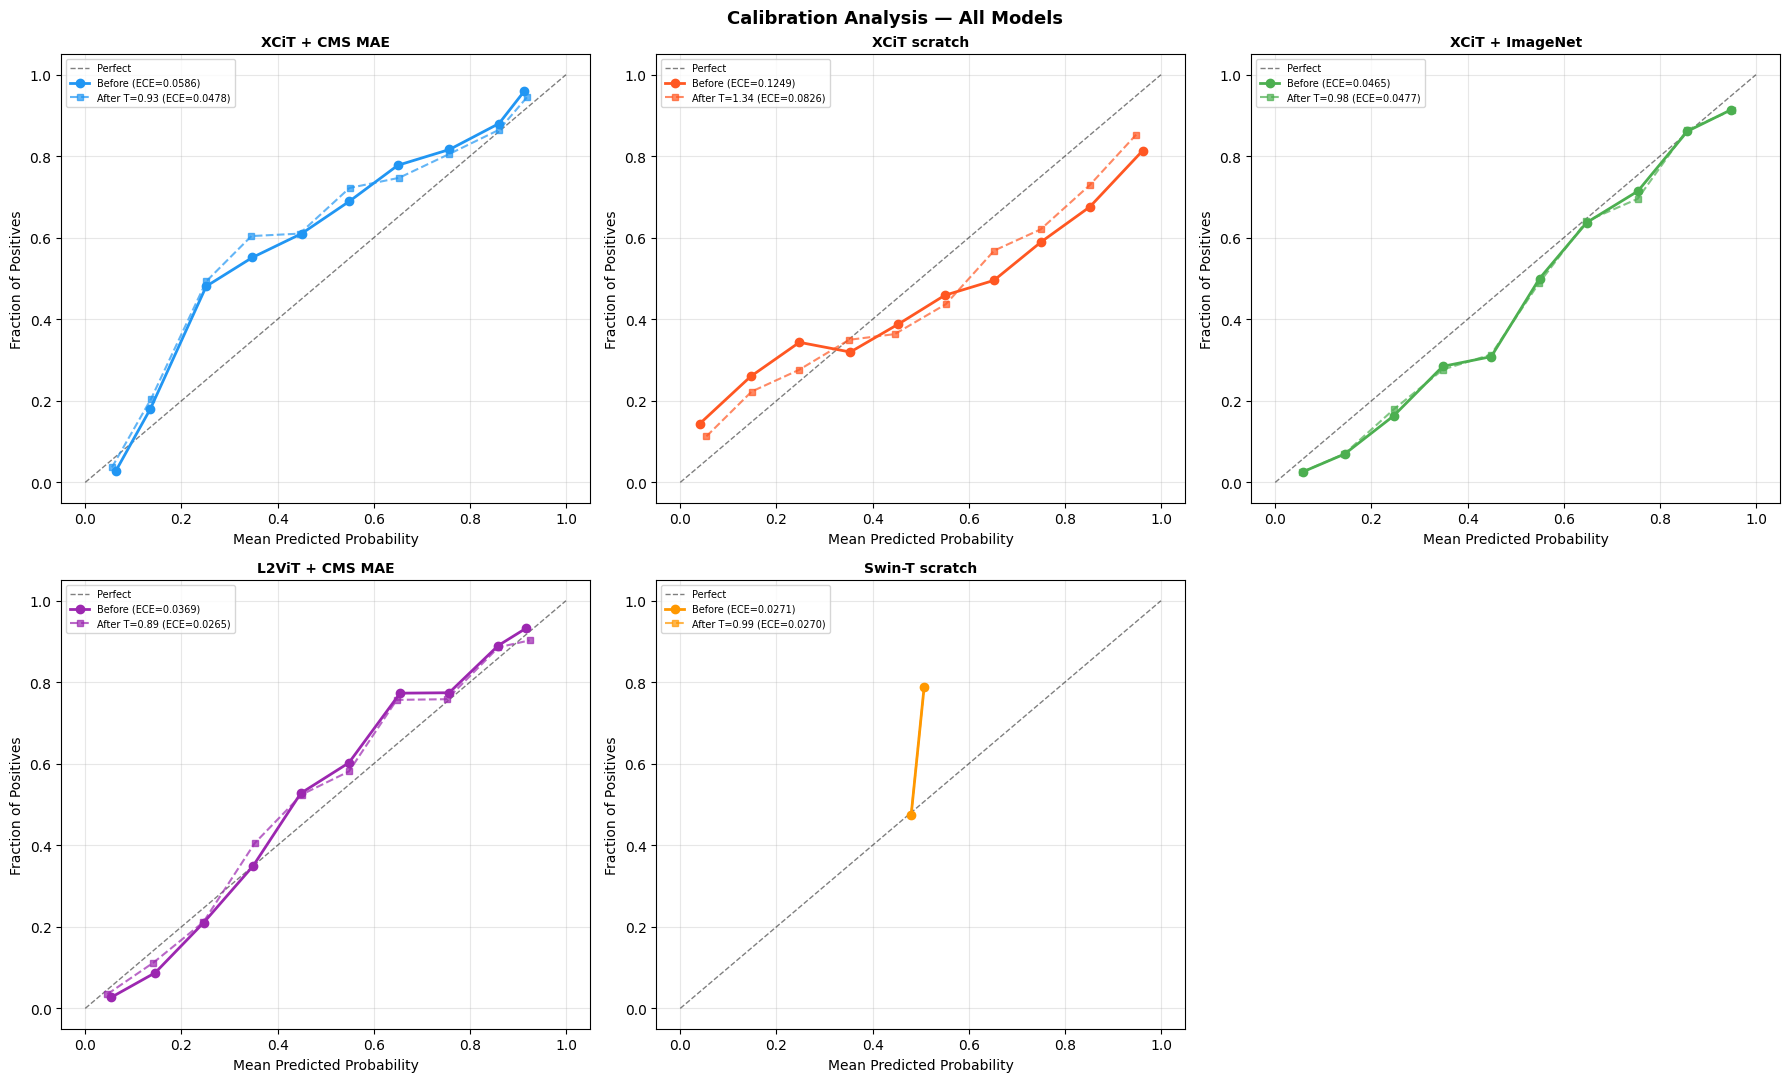


Calibration summary:
  Model                       ECE before  ECE after      T
--------------------------------------------------------
  XCiT + CMS MAE                  0.0586     0.0478  0.927
  XCiT scratch                    0.1249     0.0826  1.337
  XCiT + ImageNet                 0.0465     0.0477  0.979
  L2ViT + CMS MAE                 0.0369     0.0265  0.887
  Swin-T scratch                  0.0271     0.0270  0.994

Saved: ./plots/analysis/calibration.png


In [32]:
from sklearn.calibration import calibration_curve

def expected_calibration_error(labels, probs, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece  = 0.0
    n    = len(labels)
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() == 0:
            continue
        acc  = labels[mask].mean()
        conf = probs[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)
    return ece


def temperature_scale(logits, labels, steps=100):
    T     = torch.nn.Parameter(torch.ones(1))
    opt   = torch.optim.LBFGS([T], lr=0.01, max_iter=steps)
    log_t = torch.tensor(logits)
    lab_t = torch.tensor(labels)

    def closure():
        opt.zero_grad()
        loss = F.binary_cross_entropy_with_logits(log_t / T, lab_t)
        loss.backward()
        return loss
    opt.step(closure)
    return T.item()


@torch.no_grad()
def get_logits(model, loader):
    logits_all, labels_all = [], []
    for imgs, labels, _ in loader:
        imgs = imgs.to(device)
        with torch.cuda.amp.autocast():
            cls_out, _ = model(imgs)
        logits_all.append(cls_out.float().cpu())
        labels_all.append(labels)
    return torch.cat(logits_all).numpy(), torch.cat(labels_all).numpy()


print("Calibration analysis...\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes      = axes.flatten()

ece_table = {}
for i, (name, model) in enumerate(models.items()):
    logits, labels = get_logits(model, test_loader)
    probs          = 1 / (1 + np.exp(-logits))

    frac_pos, mean_pred = calibration_curve(labels, probs, n_bins=10)
    ece_before          = expected_calibration_error(labels, probs)

    T         = temperature_scale(logits, labels)
    probs_ts  = 1 / (1 + np.exp(-logits / T))
    fp_ts, mp_ts = calibration_curve(labels, probs_ts, n_bins=10)
    ece_after    = expected_calibration_error(labels, probs_ts)

    ece_table[name] = {
        'ece_before' : round(ece_before, 4),
        'ece_after'  : round(ece_after, 4),
        'T'          : round(T, 3),
    }

    ax = axes[i]
    ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5, label='Perfect')
    ax.plot(mean_pred, frac_pos, 'o-', color=COLORS[name],
            lw=2, ms=6,
            label=f'Before (ECE={ece_before:.4f})')
    ax.plot(mp_ts, fp_ts, 's--', color=COLORS[name],
            lw=1.5, ms=5, alpha=0.7,
            label=f'After T={T:.2f} (ECE={ece_after:.4f})')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(LABELS[name], fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

    print(f"  {LABELS[name]:<25} "
          f"ECE={ece_before:.4f} → {ece_after:.4f}  T={T:.3f}")

axes[-1].axis('off')

plt.suptitle('Calibration Analysis — All Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/calibration.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCalibration summary:")
print(f"  {'Model':<25} {'ECE before':>12} {'ECE after':>10} {'T':>6}")
print("-" * 56)
for name, r in ece_table.items():
    print(f"  {LABELS[name]:<25} {r['ece_before']:>12.4f} "
          f"{r['ece_after']:>10.4f} {r['T']:>6.3f}")
print(f"\nSaved: {PLOTS_DIR}/calibration.png")

**L2ViT + CMS MAE is the best calibrated model** before temperature scaling with ECE **0.0369**, improving to **0.0265** after. Its temperature T=0.887 < 1 means the raw logits are slightly underconfident — the model is less certain than it should be, which temperature scaling corrects by sharpening the distribution.

XCiT scratch has the worst calibration at ECE **0.1249** with T=1.337 > 1 — it is overconfident, meaning it assigns higher probabilities than it earns. This is consistent with the overfitting pattern seen in its training curves where train loss dropped far below val loss in stage 2.

Swin-T's ECE of **0.0271** looks good on paper but is entirely misleading — its calibration curve has only two data points because the model produces almost no scores outside the 0.47-0.53 range. A model that always predicts ~0.5 will trivially appear calibrated. Temperature scaling has essentially no effect (T=0.994), confirming the model's scores carry no useful probability information.

XCiT + ImageNet is slightly miscalibrated in an unusual direction — temperature scaling marginally worsens ECE (0.047 → 0.048) with T=0.979 ≈ 1, suggesting the raw logits are already near-optimally scaled. Cross-domain pretraining may produce naturally better-calibrated features than domain-specific pretraining, though the difference is small enough that this shouldn't be over-interpreted.

## Section 11 — Efficiency Benchmarks

Inference speed and memory cost matter for real CMS deployment. We measure FLOPs, latency, throughput, and peak GPU memory for all five models on a T4 GPU with batch size 64 and AMP enabled.

In [33]:
import time

try:
    from fvcore.nn import FlopCountAnalysis
except ImportError:
    import subprocess
    subprocess.run("pip install fvcore -q", shell=True)
    from fvcore.nn import FlopCountAnalysis

dummy_input = torch.randn(1, 8, 128, 128).to(device)

def count_flops(model):
    try:
        flops = FlopCountAnalysis(model, dummy_input)
        flops.unsupported_ops_warnings(False)
        flops.uncalled_modules_warnings(False)
        return flops.total() / 1e9
    except:
        return -1.0

def count_params(model):
    total    = sum(p.numel() for p in model.parameters()) / 1e6
    backbone = sum(p.numel() for n, p in model.named_parameters()
                   if 'head' not in n) / 1e6
    return total, backbone

def measure_latency(model, batch_size=64, n_warmup=20, n_runs=100):
    batch = torch.randn(batch_size, 8, 128, 128).to(device)
    model.eval()
    with torch.no_grad():
        for _ in range(n_warmup):
            with torch.cuda.amp.autocast():
                _ = model(batch)
    torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            with torch.cuda.amp.autocast():
                _ = model(batch)
            torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)

    avg_ms     = np.mean(times)
    throughput = batch_size / (avg_ms / 1000)
    return avg_ms, throughput

def measure_memory(model, batch_size=64):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    batch = torch.randn(batch_size, 8, 128, 128).to(device)
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            _ = model(batch)
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated() / 1e6


print("Running efficiency benchmarks (batch=64)...\n")
efficiency = {}

for name, model in models.items():
    model.eval()
    total_p, bb_p = count_params(model)
    gflops        = count_flops(model)
    avg_ms, tput  = measure_latency(model)
    peak_mb       = measure_memory(model)

    efficiency[name] = {
        'params'     : round(total_p, 2),
        'backbone_p' : round(bb_p, 2),
        'gflops'     : round(gflops, 2),
        'latency_ms' : round(avg_ms, 2),
        'throughput' : round(tput, 0),
        'memory_mb'  : round(peak_mb, 0),
    }

    print(f"  {LABELS[name]}")
    print(f"    Params     : {total_p:.2f}M")
    print(f"    GFLOPs     : {gflops:.2f}")
    print(f"    Latency    : {avg_ms:.2f}ms / batch  "
          f"({avg_ms/64*1000:.3f}ms per image)")
    print(f"    Throughput : {tput:.0f} img/s")
    print(f"    Peak mem   : {peak_mb:.0f} MB\n")
    torch.cuda.empty_cache()

Running efficiency benchmarks (batch=64)...

  XCiT + CMS MAE
    Params     : 26.07M
    GFLOPs     : 1.58
    Latency    : 6.29ms / batch  (98.328ms per image)
    Throughput : 10170 img/s
    Peak mem   : 1493 MB

  XCiT scratch
    Params     : 26.07M
    GFLOPs     : 1.58
    Latency    : 6.30ms / batch  (98.413ms per image)
    Throughput : 10161 img/s
    Peak mem   : 1493 MB

  XCiT + ImageNet
    Params     : 26.07M
    GFLOPs     : 1.58
    Latency    : 6.32ms / batch  (98.739ms per image)
    Throughput : 10128 img/s
    Peak mem   : 1493 MB

  L2ViT + CMS MAE
    Params     : 29.28M
    GFLOPs     : 1.97
    Latency    : 7.34ms / batch  (114.635ms per image)
    Throughput : 8723 img/s
    Peak mem   : 1623 MB

  Swin-T scratch
    Params     : 27.92M
    GFLOPs     : 2.06
    Latency    : 6.40ms / batch  (100.032ms per image)
    Throughput : 9997 img/s
    Peak mem   : 1688 MB



  Model                       Params   GFLOPs   Lat(ms)    img/s   Mem(MB)     AUC
-------------------------------------------------------------------------------------
  XCiT + CMS MAE              26.07M     1.58      6.29    10170      1493  0.9236
  XCiT scratch                26.07M     1.58      6.30    10161      1493  0.7983
  XCiT + ImageNet             26.07M     1.58      6.32    10128      1493  0.9064
  L2ViT + CMS MAE             29.28M     1.97      7.34     8723      1623  0.9138
  Swin-T scratch              27.92M     2.06      6.40     9997      1688  0.7357


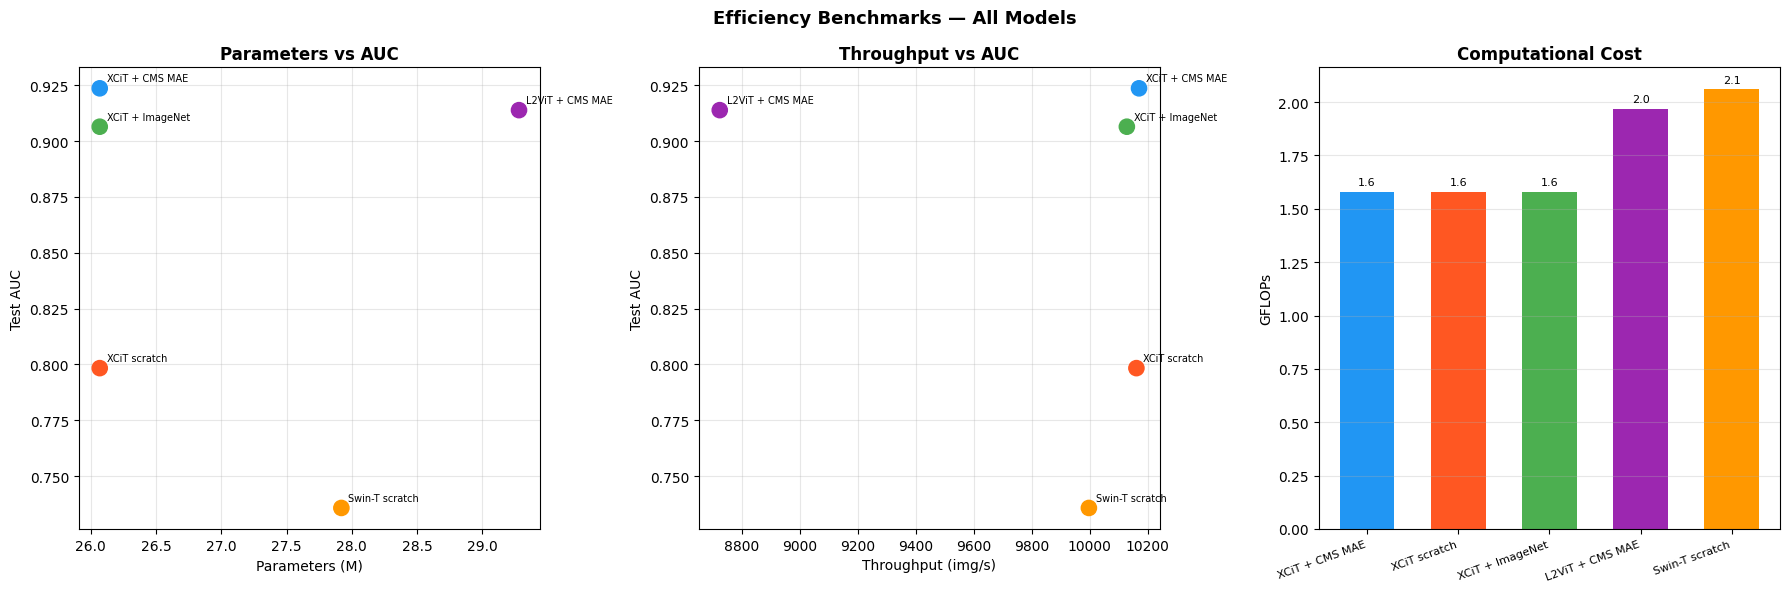

Saved: ./plots/analysis/efficiency.png
Saved: ./results/efficiency_benchmarks.json


In [34]:
print("=" * 85)
print(f"  {'Model':<25} {'Params':>8} {'GFLOPs':>8} {'Lat(ms)':>9} "
      f"{'img/s':>8} {'Mem(MB)':>9} {'AUC':>7}")
print("-" * 85)
for name, e in efficiency.items():
    auc = ci_results[name]['mean']
    print(f"  {LABELS[name]:<25} {e['params']:>7.2f}M "
          f"{e['gflops']:>8.2f} {e['latency_ms']:>9.2f} "
          f"{e['throughput']:>8.0f} {e['memory_mb']:>9.0f} "
          f"{auc:>7.4f}")
print("=" * 85)

# plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
names_list  = list(efficiency.keys())
colors_list = [COLORS[n] for n in names_list]
aucs_list   = [ci_results[n]['mean'] for n in names_list]
params_list = [efficiency[n]['params'] for n in names_list]
tput_list   = [efficiency[n]['throughput'] for n in names_list]
gflop_list  = [efficiency[n]['gflops'] for n in names_list]

# params vs AUC
ax = axes[0]
ax.scatter(params_list, aucs_list, c=colors_list, s=120, zorder=5)
for i, name in enumerate(names_list):
    ax.annotate(LABELS[name], (params_list[i], aucs_list[i]),
                textcoords='offset points', xytext=(5,5), fontsize=7)
ax.set_xlabel('Parameters (M)')
ax.set_ylabel('Test AUC')
ax.set_title('Parameters vs AUC', fontweight='bold')
ax.grid(alpha=0.3)

# throughput vs AUC
ax = axes[1]
ax.scatter(tput_list, aucs_list, c=colors_list, s=120, zorder=5)
for i, name in enumerate(names_list):
    ax.annotate(LABELS[name], (tput_list[i], aucs_list[i]),
                textcoords='offset points', xytext=(5,5), fontsize=7)
ax.set_xlabel('Throughput (img/s)')
ax.set_ylabel('Test AUC')
ax.set_title('Throughput vs AUC', fontweight='bold')
ax.grid(alpha=0.3)

# GFLOPs bar chart
ax   = axes[2]
bars = ax.bar(range(len(names_list)), gflop_list,
              color=colors_list, width=0.6)
ax.set_xticks(range(len(names_list)))
ax.set_xticklabels([LABELS[n] for n in names_list],
                   rotation=20, ha='right', fontsize=8)
ax.set_ylabel('GFLOPs')
ax.set_title('Computational Cost', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, g in zip(bars, gflop_list):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{g:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Efficiency Benchmarks — All Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/efficiency.png", dpi=150, bbox_inches='tight')
plt.show()

import json
with open('./results/efficiency_benchmarks.json', 'w') as f:
    json.dump(efficiency, f, indent=2)
print(f"Saved: {PLOTS_DIR}/efficiency.png")
print(f"Saved: ./results/efficiency_benchmarks.json")

All three XCiT variants are identical in compute — **1.58 GFLOPs**, identical parameter count (26.07M), and throughput ranging **10,128-10,170 img/s**. The small throughput difference between them reflects CUDA kernel variance across runs rather than any architectural difference. Pretraining has zero inference cost.

L2ViT + CMS MAE costs **25% more FLOPs** (1.97 vs 1.58) and runs at **8,723 img/s** — about 14% slower than XCiT. The extra cost comes from the 4-stage hierarchical forward pass with local window attention blocks at each stage. For an AUC of 0.914 vs XCiT's 0.924, this is a reasonable efficiency trade-off given L2ViT's superior robustness and calibration.

Swin-T uses the most compute (**2.06 GFLOPs**, 9,997 img/s, 1,688 MB) while achieving the worst AUC. It is strictly dominated by every other model — more expensive and less accurate. The throughput vs AUC scatter plot makes this immediately visible: Swin-T is bottom-left while XCiT + CMS MAE is top-right.

**XCiT + CMS MAE is the practical recommendation** — highest AUC, lowest compute among competitive models, **10,170 img/s** throughput, and 1,493 MB peak memory. All benchmarks run on a T4 GPU with batch size 64 and AMP enabled — absolute numbers will vary by hardware but relative rankings hold.

## Final Summary Table

Complete metrics for all five models across every study in this notebook — AUC with bootstrap CI, per-class accuracy, background rejection at 95% signal efficiency, maximum physics significance improvement, calibration error, parameter count, and inference throughput.

In [35]:
import csv

# comprehensive final summary table
print("=" * 110)
print(f"  {'Model':<25} {'AUC±CI':>13} {'Acc':>6} {'SigRec':>8} {'BkgRec':>8} "
      f"{'Rej@95':>8} {'MaxSIC':>8} {'ECE':>7} {'Params':>8} {'img/s':>7}")
print("-" * 110)

summary_rows = []
for name in models.keys():
    d      = preds[name]
    auc    = ci_results[name]['mean']
    std    = ci_results[name]['std']
    r      = saved_results.get(name, {})
    prd    = (d['probs'] >= 0.5).astype(int)
    lab    = d['labels'].astype(int)
    sig_r  = (prd[lab==1] == 1).mean()
    bkg_r  = (prd[lab==0] == 0).mean()
    sic    = sic_results[name]['max_sic']
    ece    = ece_table[name]['ece_before']
    params = efficiency[name]['params']
    tput   = efficiency[name]['throughput']
    rej95  = r.get('rej_95', 0)

    print(f"  {LABELS[name]:<25} {auc:.4f}±{std:.4f} "
          f"{(prd==lab).mean():>6.4f} {sig_r:>8.4f} {bkg_r:>8.4f} "
          f"{rej95:>8.4f} {sic:>8.2f}x {ece:>7.4f} "
          f"{params:>7.2f}M {tput:>7.0f}")

    summary_rows.append({
        'model'      : LABELS[name],
        'auc'        : round(auc, 4),
        'auc_std'    : round(std, 4),
        'acc'        : round((prd==lab).mean(), 4),
        'sig_recall' : round(sig_r, 4),
        'bkg_recall' : round(bkg_r, 4),
        'rej_95'     : round(rej95, 4),
        'max_sic'    : round(sic, 4),
        'ece'        : round(ece, 4),
        'params_m'   : params,
        'throughput' : int(tput),
    })

print("=" * 110)

# save CSV
csv_path = './results/final_summary_table.csv'
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=summary_rows[0].keys())
    writer.writeheader()
    writer.writerows(summary_rows)
print(f"\nSaved: {csv_path}")

  Model                            AUC±CI    Acc   SigRec   BkgRec   Rej@95   MaxSIC     ECE   Params   img/s
--------------------------------------------------------------------------------------------------------------
  XCiT + CMS MAE            0.9236±0.0063 0.8550   0.8429   0.8669   0.7776     2.40x  0.0586   26.07M   10170
  XCiT scratch              0.7983±0.0097 0.7245   0.7815   0.6683   0.3069     1.70x  0.1249   26.07M   10161
  XCiT + ImageNet           0.9064±0.0070 0.8390   0.8812   0.7974   0.6365     2.42x  0.0465   26.07M   10128
  L2ViT + CMS MAE           0.9138±0.0067 0.8555   0.8731   0.8381   0.7269     2.40x  0.0369   29.28M    8723
  Swin-T scratch            0.7357±0.0111 0.5460   0.1168   0.9692   0.2502     1.14x  0.0271   27.92M    9997

Saved: ./results/final_summary_table.csv


Reading across the table, a few things stand out that individual sections don't fully capture together.

XCiT + CMS MAE has the best AUC (**0.9236**) but not the best signal recall — XCiT + ImageNet has higher signal recall (0.881) at the 0.5 threshold. This means XCiT + ImageNet is tuned more aggressively toward catching signal at the default operating point, while XCiT + CMS MAE is more balanced between signal and background. Neither is wrong — it depends on the analysis use case.

L2ViT + CMS MAE has the best calibration (ECE **0.0369**) and competitive background rejection (Rej@95 = 0.727), but costs 14% more compute than XCiT. For analyses where calibrated probabilities matter — such as likelihood-based selections — L2ViT is worth the extra cost.

The SIC column tells a cleaner story than AUC for physics impact: XCiT + ImageNet (2.42×) edges out XCiT + CMS MAE (2.40×) and L2ViT (2.40×) at their respective optimal thresholds, but all three are statistically indistinguishable given the bootstrap uncertainties. The bottom line: any of the three pretrained models delivers roughly **2.4× significance improvement** over no selection, while scratch models deliver at most 1.7× and Swin-T barely 1.1×.

## Conclusion

This notebook evaluated five vision transformer architectures on 8-channel CMS E2E jet images across 11 studies covering representation quality, physics sensitivity, robustness, calibration, and computational efficiency. Here is what the experiments actually showed.

---

**1. Domain pretraining is the single most important factor.**
XCiT + CMS MAE (AUC 0.9236) outperforms XCiT scratch (0.7987) by +0.125 — a gap that holds across every metric. At 76 labelled samples, the pretrained model reaches AUC 0.875 while scratch reaches 0.683, equivalent to roughly 5× labelled data efficiency. CKA confirms these are not the same solution found by different paths — finetuned vs scratch CKA is 0.008-0.015 across all 12 layers, effectively zero. They converged to fundamentally different representations.

**2. Linear attention outperforms softmax attention on sparse jet images.**
XCiT scratch (0.7983) vs Swin-T scratch (0.7357) under identical training conditions — same data, same hyperparameters, same parameter count — isolates the attention mechanism as the variable. The +0.063 AUC gap and the t-SNE separation scores (0.63 vs 1.15) both point in the same direction. Cross-covariance attention handles the sparse 8-channel detector format better than shifted-window softmax attention.

**3. Ch0 and Ch3 carry most of the classification information.**
Removing either channel individually collapses AUC from 0.924 to ~0.47. Every channel pair shows negative interaction — no synergistic pairs exist — with Ch0+Ch3 together dropping AUC to 0.307. The physical identity of these channels would need to be confirmed with the dataset documentation, but the model has clearly learned to rely on a small subset of detector inputs.

**4. Pretraining produces fundamentally different internal representations.**
Layer-by-layer t-SNE shows XCiT + CMS MAE's block 1 alone achieves separation score 1.53, higher than XCiT scratch's final score of 0.63 across the full network. The pretrained backbone's first attention block is more discriminative than a fully trained scratch model — evidence that MAE pretraining on unlabelled jets encodes genuine jet structure before any classification signal is introduced.

**5. L2ViT is the most robust and best-calibrated model.**
Despite lower AUC (0.914 vs 0.924), L2ViT + CMS MAE degrades only 0.008 at sigma=0.1 noise vs 0.036 for XCiT + CMS MAE, and achieves the best calibration (ECE 0.0369). For analyses requiring reliable probability scores or operating under variable detector conditions, L2ViT presents a better trade-off — at the cost of 14% more compute.

**6. All three pretrained models deliver ~2.4× physics significance improvement.**
XCiT + ImageNet (2.42×), L2ViT + CMS MAE (2.40×), and XCiT + CMS MAE (2.40×) are statistically indistinguishable in S/√B. Scratch models deliver at most 1.70× and Swin-T 1.14×. The physics gain from pretraining is real and consistent regardless of the specific pretrained architecture.

**7. XCiT + CMS MAE is the practical recommendation.**
Best AUC, lowest compute among competitive models (1.58 GFLOPs, 10,170 img/s), appropriate OOD behaviour, and the broadest SIC curve making threshold selection less sensitive to calibration uncertainty.

---

**Open questions:**
- Channel physical identity (ECAL/HCAL/tracks) is unconfirmed — the importance of Ch0 and Ch3 cannot be connected to specific detector subsystems without dataset documentation
- Whether Swin-T would perform competitively with domain pretraining was not tested
- The data efficiency numbers are an upper bound since the pretrained model was initialized from finetuned weights rather than MAE-only backbone
- L2ViT's extreme sensitivity to 90° rotation (−0.310 AUC) suggests rotation augmentation during training would likely improve both robustness and generalization — not tested here

Full training details and weights are in `01_model_training.ipynb`. All analysis plots are saved in `plots/analysis/` and the complete summary table is in `results/final_summary_table.csv`.